# ACTIVIDAD 10: COMPARACIÓN DE ARQUITECTURAS - Detección de Polvo en Paneles Solares

---

En esta actividad, vamos a comparar **3 arquitecturas diferentes** de redes neuronales para resolver el problema de clasificación de imágenes de paneles solares (detectar si están limpios o con polvo):

1. **Red Neuronal Densa (DNN)** - Baseline con capas fully connected
2. **Red Neuronal Convolucional (CNN)** - CNN entrenada desde cero
3. **Transfer Learning (CNN pre-entrenada)** - Aprovechando modelos pre-entrenados

**Dataset:** Solar Panel Dust Detection

[Dataset en Kaggle](https://www.kaggle.com/datasets/hemanthsai7/solar-panel-dust-detection)

**Objetivo:** Comparar el rendimiento de las 3 arquitecturas y determinar cuál es más efectiva para este problema.

**Ventajas de cada arquitectura:**
- **DNN**: Simple, rápida, baseline para comparación
- **CNN**: Aprende características espaciales, mejor para imágenes
- **Transfer Learning**: Aprovecha conocimiento previo, mejor generalización con menos datos

## Instalación de Dependencias

**⚠️ IMPORTANTE:** Ejecuta esta celda solo si necesitas instalar las dependencias. Si ya tienes un entorno configurado (como `venv_tf_gpu`), puedes omitir esta celda.

**Versiones específicas para compatibilidad:**
- TensorFlow 2.10.0 (última versión compatible con Python 3.9 y GPU)
- NumPy < 2.0 (TensorFlow 2.10 no es compatible con NumPy 2.x)
- OpenCV < 4.10 (compatible con NumPy 1.x)

In [1]:
!pip install "opencv-python<4.10"
!pip install pandas scikit-learn
!pip install matplotlib seaborn
!pip install kagglehub
!pip install tensorflow==2.10.0 tensorflow-gpu==2.10.0
!pip install "numpy<2.0"

## Configuración Inicial - GPU

In [2]:
# Configurar TensorFlow para usar GPU
import os
import tensorflow as tf

print("="*80)
print("CONFIGURACIÓN DE GPU CON TENSORFLOW")
print("="*80 + "\n")

# Verificar versión de TensorFlow
print(f"TensorFlow version: {tf.__version__}")

# Configurar para usar GPU si está disponible
gpus = tf.config.list_physical_devices('GPU')
print(f"\nGPUs detectadas: {len(gpus)}")

if gpus:
    try:
        # Permitir crecimiento de memoria para evitar que TensorFlow reserve toda la VRAM
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        
        print(f"✅ GPU configurada correctamente")
        print(f"   Dispositivo: {gpus[0].name}")
        
        # Información adicional de la GPU
        gpu_details = tf.config.experimental.get_device_details(gpus[0])
        if 'device_name' in gpu_details:
            print(f"   Nombre: {gpu_details['device_name']}")
        
    except RuntimeError as e:
        print(f"⚠️ Error configurando GPU: {e}")
else:
    print("⚠️ No se detectaron GPUs. Se usará CPU (entrenamiento más lento)")
    print("   Asegúrate de tener CUDA y cuDNN instalados correctamente.")

# Verificar dispositivo por defecto
print(f"\nDispositivo por defecto: {tf.test.gpu_device_name() if tf.test.is_gpu_available() else 'CPU'}")

print("\n" + "="*80)

CONFIGURACIÓN DE GPU CON TENSORFLOW

TensorFlow version: 2.10.0

GPUs detectadas: 1
✅ GPU configurada correctamente
   Dispositivo: /physical_device:GPU:0
   Nombre: NVIDIA GeForce RTX 4060 Ti
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.

Dispositivo por defecto: /device:GPU:0



## Importación de Librerías

In [3]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0, MobileNetV2
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support

# Configurar semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ Librerías importadas correctamente")
print(f"   Keras version: {keras.__version__}")
print(f"   Numpy version: {np.__version__}")

✅ Librerías importadas correctamente
   Keras version: 2.10.0
   Numpy version: 1.26.4


## Descarga del Dataset

In [4]:
# Descargar el dataset desde Kaggle usando kagglehub
!pip install -q kagglehub

import kagglehub

print("="*80)
print("DESCARGA DEL DATASET DE DETECCIÓN DE POLVO EN PANELES SOLARES")
print("="*80 + "\n")

print("Descargando dataset de Solar Panel Dust Detection desde Kaggle...")
print("Esto puede tardar varios minutos dependiendo de tu conexión...\n")

try:
    # Descargar la última versión del dataset
    path = kagglehub.dataset_download("hemanthsai7/solar-panel-dust-detection")

    print(f"\n✅ Dataset descargado correctamente en: {path}")
    print(f"\nContenido del directorio:")

    for item in os.listdir(path):
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            # Contar archivos de imagen
            image_files = [f for f in os.listdir(item_path) 
                          if f.lower().endswith(('.jpeg', '.jpg', '.png', '.bmp'))]
            print(f"  📁 {item}/ ({len(image_files)} imágenes)")
        else:
            print(f"  📄 {item}")

except Exception as e:
    print(f"\n❌ Error al descargar el dataset: {e}")
    raise

print("\n" + "="*80)

DESCARGA DEL DATASET DE DETECCIÓN DE POLVO EN PANELES SOLARES

Descargando dataset de Solar Panel Dust Detection desde Kaggle...
Esto puede tardar varios minutos dependiendo de tu conexión...


✅ Dataset descargado correctamente en: C:\Users\TRENDINGPC\.cache\kagglehub\datasets\hemanthsai7\solar-panel-dust-detection\versions\1

Contenido del directorio:
  📁 Detect_solar_dust/ (0 imágenes)



## Configuración y Carga de Datos

In [5]:
# Configuración
IMG_SIZE = 224  # Tamaño estándar para modelos pre-entrenados (VGG, ResNet, etc.)
BATCH_SIZE = 32
EPOCHS = 50

# Explorar la estructura del dataset
print("="*80)
print("EXPLORACIÓN DEL DATASET")
print("="*80 + "\n")

if 'path' in locals():
    print(f"Ruta del dataset: {path}\n")
    
    # Buscar carpeta principal del dataset (Detect_solar_dust)
    dataset_root = None
    for item in os.listdir(path):
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            # Verificar si contiene Clean y Dusty
            subdirs = os.listdir(item_path) if os.path.exists(item_path) else []
            if 'Clean' in subdirs and 'Dusty' in subdirs:
                dataset_root = item_path
                break
    
    # Si no se encuentra, verificar en la ruta principal
    if dataset_root is None:
        subdirs = os.listdir(path)
        if 'Clean' in subdirs and 'Dusty' in subdirs:
            dataset_root = path
    
    if dataset_root:
        DATASET_PATH = dataset_root
        
        print(f"📁 Estructura del dataset:")
        print(f"   Root: {dataset_root}\n")
        
        # Explorar clases
        class_folders = []
        for item in ['Clean', 'Dusty']:
            item_path = os.path.join(dataset_root, item)
            if os.path.exists(item_path) and os.path.isdir(item_path):
                image_files = [f for f in os.listdir(item_path) 
                             if f.lower().endswith(('.jpeg', '.jpg', '.png', '.bmp'))]
                if image_files:
                    class_folders.append(item)
                    print(f"📁 Clase: {item} ({len(image_files)} imágenes)")
        
        if class_folders:
            # Mapeo de clases
            MAP_CLASSES = {i: folder for i, folder in enumerate(sorted(class_folders))}
            CLASS_NAMES = {i: folder.replace('_', ' ').title() for i, folder in enumerate(sorted(class_folders))}
            
            print(f"\n✅ Encontradas {len(MAP_CLASSES)} clases:")
            for idx, name in CLASS_NAMES.items():
                print(f"   {idx}: {name}")
        else:
            print("❌ No se encontraron carpetas con imágenes")
    else:
        print("❌ No se encontró la estructura Clean/Dusty en el dataset")
else:
    print("❌ Variable 'path' no encontrada. Ejecuta la celda de descarga primero.")

print("\n" + "="*80)


EXPLORACIÓN DEL DATASET

Ruta del dataset: C:\Users\TRENDINGPC\.cache\kagglehub\datasets\hemanthsai7\solar-panel-dust-detection\versions\1

📁 Estructura del dataset:
   Root: C:\Users\TRENDINGPC\.cache\kagglehub\datasets\hemanthsai7\solar-panel-dust-detection\versions\1\Detect_solar_dust

📁 Clase: Clean (1493 imágenes)
📁 Clase: Dusty (1069 imágenes)

✅ Encontradas 2 clases:
   0: Clean
   1: Dusty



In [6]:
def load_solar_panel_dataset(dirname, map_classes, img_size=224, verbose=True):
    """Carga el dataset de paneles solares.
    
    Args:
        dirname: directorio con las imágenes organizadas por carpetas (Clean, Dusty)
        map_classes: diccionario de mapeo clase -> nombre de carpeta
        img_size: tamaño al que redimensionar las imágenes
        verbose: mostrar información de progreso
    
    Returns:
        X, y: arrays con imágenes y etiquetas
    """
    X_data = []
    y_data = []
    
    for label, class_name in map_classes.items():
        class_path = os.path.join(dirname, class_name)
        
        if not os.path.exists(class_path):
            if verbose:
                print(f"⚠️ Carpeta no encontrada: {class_path}")
            continue
        
        files = os.listdir(class_path)
        images = [f for f in files if f.lower().endswith(('.jpeg', '.jpg', '.png', '.bmp'))]
        
        if verbose:
            print(f"Cargando {len(images)} imágenes de '{CLASS_NAMES[label]}'...")
        
        for i, image_name in enumerate(images):
            try:
                image_path = os.path.join(class_path, image_name)
                image = cv2.imread(image_path)
                
                if image is not None:
                    # Convertir de BGR a RGB
                    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                    # Redimensionar
                    image = cv2.resize(image, (img_size, img_size))
                    
                    X_data.append(image)
                    y_data.append(label)
                else:
                    if verbose and i < 5:  # Solo mostrar algunos errores
                        print(f"  ⚠️ No se pudo leer: {image_name}")
            except Exception as e:
                if verbose and i < 5:
                    print(f"  ⚠️ Error procesando {image_name}: {e}")
    
    return np.array(X_data), np.array(y_data)

print("✅ Función de carga definida")

✅ Función de carga definida


In [7]:
# Cargar el dataset
print("="*80)
print("CARGANDO DATASET DE PANELES SOLARES")
print("="*80 + "\n")

# Cargar todos los datos
print("Cargando todas las imágenes del dataset...")
X_all, y_all = load_solar_panel_dataset(DATASET_PATH, MAP_CLASSES, img_size=IMG_SIZE)

print(f"\n✅ Dataset cargado exitosamente!")
print(f"\n📊 Total de imágenes: {len(X_all):,}")
print(f"   Forma de X_all: {X_all.shape}")
print(f"   Clases únicas: {np.unique(y_all)}")
print(f"   Rango de valores de píxeles: [{X_all.min()}, {X_all.max()}]")

# Dividir en train (80%) y test (20%)
print("\nDividiendo dataset en TRAIN (80%) y TEST (20%)...")
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.20,
    random_state=SEED,
    stratify=y_all
)

print(f"\n📊 Conjunto de TRAIN:")
print(f"   Total de imágenes: {len(X_train):,}")
print(f"   Forma de X_train: {X_train.shape}")
print(f"   Clases únicas: {np.unique(y_train)}")

print(f"\n📊 Conjunto de TEST:")
print(f"   Total de imágenes: {len(X_test):,}")
print(f"   Forma de X_test: {X_test.shape}")
print(f"   Clases únicas: {np.unique(y_test)}")

print("\n" + "="*80)


CARGANDO DATASET DE PANELES SOLARES

Cargando todas las imágenes del dataset...
Cargando 1493 imágenes de 'Clean'...
Cargando 1069 imágenes de 'Dusty'...

✅ Dataset cargado exitosamente!

📊 Total de imágenes: 2,561
   Forma de X_all: (2561, 224, 224, 3)
   Clases únicas: [0 1]
   Rango de valores de píxeles: [0, 255]

Dividiendo dataset en TRAIN (80%) y TEST (20%)...

📊 Conjunto de TRAIN:
   Total de imágenes: 2,048
   Forma de X_train: (2048, 224, 224, 3)
   Clases únicas: [0 1]

📊 Conjunto de TEST:
   Total de imágenes: 513
   Forma de X_test: (513, 224, 224, 3)
   Clases únicas: [0 1]



## Análisis Exploratorio de Datos

ANÁLISIS EXPLORATORIO DEL DATASET DE PANELES SOLARES

--- Distribución de Clases en TRAIN ---
Clase  Cantidad  Porcentaje
Clean      1193       58.25
Dusty       855       41.75

--- Distribución de Clases en TEST ---
Clase  Cantidad  Porcentaje
Clean       299       58.28
Dusty       214       41.72


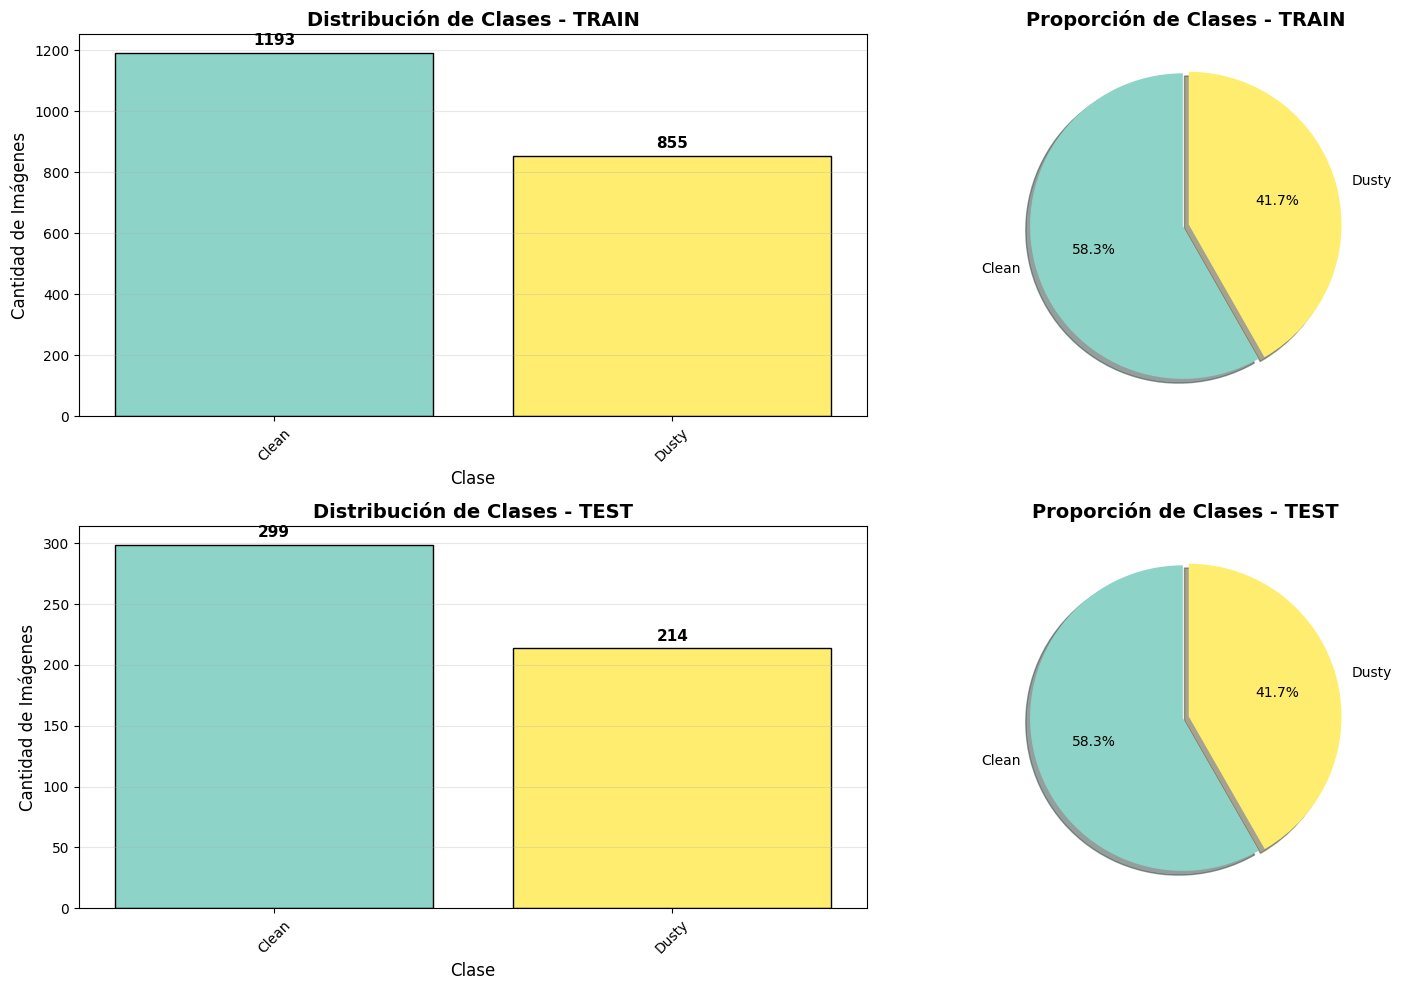

In [8]:
print("="*80)
print("ANÁLISIS EXPLORATORIO DEL DATASET DE PANELES SOLARES")
print("="*80 + "\n")

# Distribución de clases en TRAIN
print("--- Distribución de Clases en TRAIN ---")
unique_train, counts_train = np.unique(y_train, return_counts=True)
df_dist_train = pd.DataFrame({
    'Clase': [CLASS_NAMES[i] for i in unique_train],
    'Cantidad': counts_train,
    'Porcentaje': (counts_train / len(y_train) * 100).round(2)
})
print(df_dist_train.to_string(index=False))

# Distribución de clases en TEST
print("\n--- Distribución de Clases en TEST ---")
unique_test, counts_test = np.unique(y_test, return_counts=True)
df_dist_test = pd.DataFrame({
    'Clase': [CLASS_NAMES[i] for i in unique_test],
    'Cantidad': counts_test,
    'Porcentaje': (counts_test / len(y_test) * 100).round(2)
})
print(df_dist_test.to_string(index=False))

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

colors = plt.cm.Set3(np.linspace(0, 1, len(unique_train)))

# TRAIN - Gráfico de barras
ax1 = axes[0, 0]
ax1.bar([CLASS_NAMES[i] for i in unique_train], counts_train, color=colors, edgecolor='black')
ax1.set_xlabel('Clase', fontsize=12)
ax1.set_ylabel('Cantidad de Imágenes', fontsize=12)
ax1.set_title('Distribución de Clases - TRAIN', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
for i, (v, c) in enumerate(zip(counts_train, counts_train)):
    ax1.text(i, v + max(counts_train)*0.02, str(c), ha='center', fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# TRAIN - Gráfico circular
ax2 = axes[0, 1]
ax2.pie(counts_train, labels=[CLASS_NAMES[i] for i in unique_train], autopct='%1.1f%%',
        colors=colors, explode=[0.02]*len(unique_train), shadow=True, startangle=90)
ax2.set_title('Proporción de Clases - TRAIN', fontsize=14, fontweight='bold')

# TEST - Gráfico de barras
ax3 = axes[1, 0]
ax3.bar([CLASS_NAMES[i] for i in unique_test], counts_test, color=colors, edgecolor='black')
ax3.set_xlabel('Clase', fontsize=12)
ax3.set_ylabel('Cantidad de Imágenes', fontsize=12)
ax3.set_title('Distribución de Clases - TEST', fontsize=14, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
for i, (v, c) in enumerate(zip(counts_test, counts_test)):
    ax3.text(i, v + max(counts_test)*0.02, str(c), ha='center', fontsize=11, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# TEST - Gráfico circular
ax4 = axes[1, 1]
ax4.pie(counts_test, labels=[CLASS_NAMES[i] for i in unique_test], autopct='%1.1f%%',
        colors=colors, explode=[0.02]*len(unique_test), shadow=True, startangle=90)
ax4.set_title('Proporción de Clases - TEST', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)


Visualizando muestras del dataset de TRAIN...



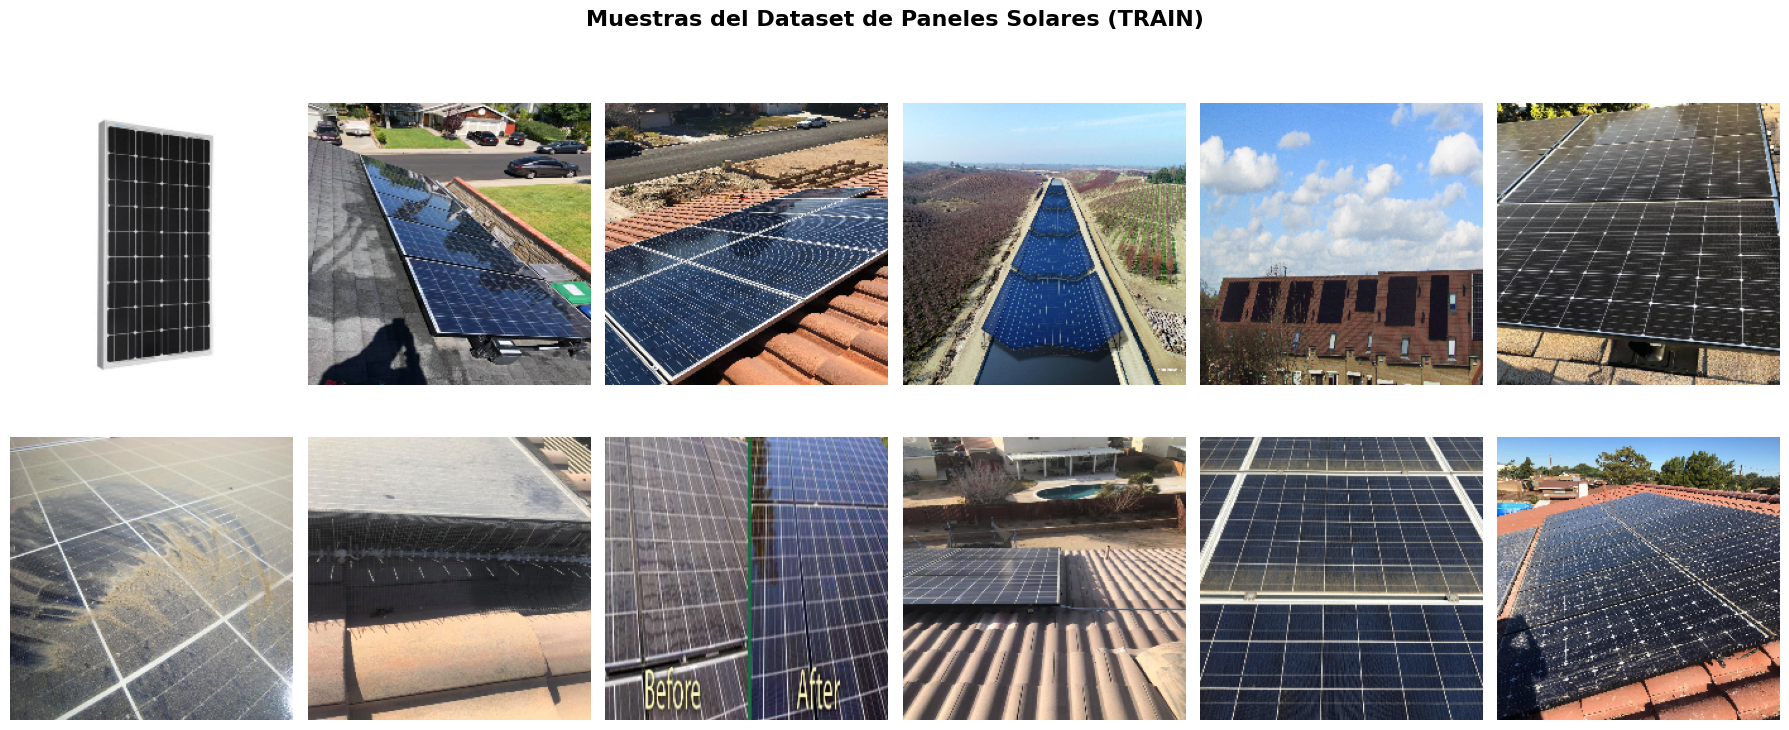

In [9]:
# Visualizar muestras de cada clase (de TRAIN)
print("Visualizando muestras del dataset de TRAIN...\n")

n_classes = len(MAP_CLASSES)
samples_per_class = 6

fig, axes = plt.subplots(n_classes, samples_per_class, figsize=(18, 4*n_classes))

if n_classes == 1:
    axes = [axes]

for idx, label in enumerate(sorted(MAP_CLASSES.keys())):
    indices = np.where(y_train == label)[0]
    np.random.shuffle(indices)
    
    for i in range(min(samples_per_class, len(indices))):
        ax = axes[idx][i] if n_classes > 1 else axes[i]
        ax.imshow(X_train[indices[i]])
        ax.axis('off')
        if i == 0:
            ax.set_ylabel(CLASS_NAMES[label], fontsize=12, rotation=0, 
                         ha='right', va='center')

plt.suptitle('Muestras del Dataset de Paneles Solares (TRAIN)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## Preparación de Datos

In [10]:
print("="*80)
print("PREPARACIÓN DE DATOS")
print("="*80 + "\n")

# Normalizar las imágenes (importante para Transfer Learning)
print("Normalizando imágenes para Transfer Learning...")
# Los modelos pre-entrenados esperan valores en [0, 1] o normalizados según ImageNet
X_train_normalized = X_train.astype('float32') / 255.0
X_test_normalized = X_test.astype('float32') / 255.0

print(f"Rango normalizado TRAIN: [{X_train_normalized.min():.2f}, {X_train_normalized.max():.2f}]")
print(f"Rango normalizado TEST: [{X_test_normalized.min():.2f}, {X_test_normalized.max():.2f}]")

# Convertir etiquetas a one-hot encoding
print("\nConvirtiendo etiquetas a one-hot encoding...")
y_train_categorical = keras.utils.to_categorical(y_train, len(MAP_CLASSES))
y_test_categorical = keras.utils.to_categorical(y_test, len(MAP_CLASSES))
print(f"Forma de y_train_categorical: {y_train_categorical.shape}")
print(f"Forma de y_test_categorical: {y_test_categorical.shape}")

# Crear conjunto de VALIDATION a partir de TRAIN (20% del train)
print("\nCreando conjunto de VALIDATION a partir de TRAIN (80/20)...")
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_normalized, y_train_categorical,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train
)

# Etiquetas sin one-hot para métricas
y_train_labels = np.argmax(y_train_final, axis=1)
y_val_labels = np.argmax(y_val, axis=1)
y_test_labels = np.argmax(y_test_categorical, axis=1)

print(f"\n📊 Resumen de la división final:")
print(f"   Training: {X_train_final.shape[0]:,} imágenes ({X_train_final.shape[0]/(len(X_train)+len(X_test))*100:.1f}% del total)")
print(f"   Validation: {X_val.shape[0]:,} imágenes ({X_val.shape[0]/(len(X_train)+len(X_test))*100:.1f}% del total)")
print(f"   Test: {X_test_normalized.shape[0]:,} imágenes ({len(X_test)/(len(X_train)+len(X_test))*100:.1f}% del total)")

# Verificar distribución
print("\n📊 Distribución de clases por conjunto:")
for name, labels in [("Training", y_train_labels),
                      ("Validation", y_val_labels),
                      ("Test", y_test_labels)]:
    unique_labels, counts_labels = np.unique(labels, return_counts=True)
    dist_str = ", ".join([f"{CLASS_NAMES[l]}={c}" for l, c in zip(unique_labels, counts_labels)])
    print(f"   {name}: {dist_str}")

print("\n" + "="*80)


PREPARACIÓN DE DATOS

Normalizando imágenes para Transfer Learning...
Rango normalizado TRAIN: [0.00, 1.00]
Rango normalizado TEST: [0.00, 1.00]

Convirtiendo etiquetas a one-hot encoding...
Forma de y_train_categorical: (2048, 2)
Forma de y_test_categorical: (513, 2)

Creando conjunto de VALIDATION a partir de TRAIN (80/20)...

📊 Resumen de la división final:
   Training: 1,638 imágenes (64.0% del total)
   Validation: 410 imágenes (16.0% del total)
   Test: 513 imágenes (20.0% del total)

📊 Distribución de clases por conjunto:
   Training: Clean=954, Dusty=684
   Validation: Clean=239, Dusty=171
   Test: Clean=299, Dusty=214



## MODELO 1: Red Neuronal Densa (DNN)

In [11]:
print("="*80)
print("MODELO 1: RED NEURONAL DENSA (DNN)")
print("="*80 + "\n")

print("Características de las redes neuronales densas:")
print("  • Todas las neuronas están conectadas entre capas")
print("  • No explotan la estructura espacial de las imágenes")
print("  • Requieren aplanar las imágenes (pérdida de información espacial)")
print("  • Sirven como baseline para comparación\n")

# Aplanar las imágenes para DNN
print("Preparando datos para DNN (aplanando imágenes)...")
X_train_flat = X_train_final.reshape(X_train_final.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test_normalized.reshape(X_test_normalized.shape[0], -1)

print(f"Forma original: {X_train_final.shape}")
print(f"Forma aplanada: {X_train_flat.shape}")
print(f"Tamaño de entrada: {X_train_flat.shape[1]:,} features\n")

# Construir modelo DNN
print("Construyendo modelo DNN...")

model_dnn = models.Sequential([
    layers.Input(shape=(IMG_SIZE * IMG_SIZE * 3,)),
    
    layers.Dense(512, activation='relu', name='dense1'),
    layers.BatchNormalization(name='bn1'),
    layers.Dropout(0.5, name='dropout1'),
    
    layers.Dense(256, activation='relu', name='dense2'),
    layers.BatchNormalization(name='bn2'),
    layers.Dropout(0.5, name='dropout2'),
    
    layers.Dense(128, activation='relu', name='dense3'),
    layers.BatchNormalization(name='bn3'),
    layers.Dropout(0.5, name='dropout3'),
    
    layers.Dense(len(MAP_CLASSES), activation='softmax', name='output')
], name='DNN_Model')

# Compilar
model_dnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n✅ Modelo DNN compilado")
print("\n--- Resumen del Modelo DNN ---")
model_dnn.summary()

# Información de parámetros
trainable_params_dnn = np.sum([np.prod(v.shape) for v in model_dnn.trainable_weights])
print(f"\n📊 Parámetros entrenables: {trainable_params_dnn:,}")

print("\n" + "="*80)

MODELO 1: RED NEURONAL DENSA (DNN)

Características de las redes neuronales densas:
  • Todas las neuronas están conectadas entre capas
  • No explotan la estructura espacial de las imágenes
  • Requieren aplanar las imágenes (pérdida de información espacial)
  • Sirven como baseline para comparación

Preparando datos para DNN (aplanando imágenes)...
Forma original: (1638, 224, 224, 3)
Forma aplanada: (1638, 150528)
Tamaño de entrada: 150,528 features

Construyendo modelo DNN...

✅ Modelo DNN compilado

--- Resumen del Modelo DNN ---
Model: "DNN_Model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense1 (Dense)              (None, 512)               77070848  
                                                                 
 bn1 (BatchNormalization)    (None, 512)               2048      
                                                                 
 dropout1 (Dropout)          (None, 512)     

In [12]:
print("="*80)
print("ENTRENAMIENTO MODELO 1: DNN")
print("="*80 + "\n")

# Convertir a float32
X_train_flat = X_train_flat.astype(np.float32)
X_val_flat   = X_val_flat.astype(np.float32)
y_train_final = y_train_final.astype(np.float32)
y_val = y_val.astype(np.float32)

# --------------------------
# Dataset con generador
# --------------------------
def train_gen():
    for x, y in zip(X_train_flat, y_train_final):
        yield x, y

train_dataset = tf.data.Dataset.from_generator(
    train_gen,
    output_signature=(
        tf.TensorSpec(shape=X_train_flat.shape[1:], dtype=tf.float32),
        tf.TensorSpec(shape=y_train_final.shape[1:], dtype=tf.float32)
    )
).shuffle(1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

def val_gen():
    for x, y in zip(X_val_flat, y_val):
        yield x, y

val_dataset = tf.data.Dataset.from_generator(
    val_gen,
    output_signature=(
        tf.TensorSpec(shape=X_val_flat.shape[1:], dtype=tf.float32),
        tf.TensorSpec(shape=y_val.shape[1:], dtype=tf.float32)
    )
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# --------------------------
# Callbacks
# --------------------------
callbacks_dnn = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("Iniciando entrenamiento del modelo DNN...\n")

history_dnn = model_dnn.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=callbacks_dnn,
    verbose=1
)

print("\n" + "="*80)
print("ENTRENAMIENTO DNN COMPLETADO")
print("="*80)


ENTRENAMIENTO MODELO 1: DNN

Iniciando entrenamiento del modelo DNN...

Epoch 1/50
52/52 [==============================] - 3s 35ms/step - loss: 1.0783 - accuracy: 0.5739 - val_loss: 3.0878 - val_accuracy: 0.5829 - lr: 0.0010
Epoch 2/50
52/52 [==============================] - 2s 28ms/step - loss: 0.9160 - accuracy: 0.6093 - val_loss: 1.0317 - val_accuracy: 0.5634 - lr: 0.0010
Epoch 3/50
52/52 [==============================] - 1s 27ms/step - loss: 0.8784 - accuracy: 0.6166 - val_loss: 0.6838 - val_accuracy: 0.6415 - lr: 0.0010
Epoch 4/50
52/52 [==============================] - 1s 27ms/step - loss: 0.7965 - accuracy: 0.6172 - val_loss: 0.6420 - val_accuracy: 0.6634 - lr: 0.0010
Epoch 5/50
52/52 [==============================] - 1s 24ms/step - loss: 0.7446 - accuracy: 0.6190 - val_loss: 0.6638 - val_accuracy: 0.6415 - lr: 0.0010
Epoch 6/50
52/52 [==============================] - 1s 27ms/step - loss: 0.6787 - accuracy: 0.6618 - val_loss: 0.6289 - val_accuracy: 0.7000 - lr: 0.0010
Epoc

In [13]:
# Convertir test a float32
X_test_flat = X_test_flat.astype(np.float32)
y_test_categorical = y_test_categorical.astype(np.float32)

def test_gen():
    for x, y in zip(X_test_flat, y_test_categorical):
        yield x, y

test_dataset = tf.data.Dataset.from_generator(
    test_gen,
    output_signature=(
        tf.TensorSpec(shape=X_test_flat.shape[1:], dtype=tf.float32),
        tf.TensorSpec(shape=y_test_categorical.shape[1:], dtype=tf.float32)
    )
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Evaluación
test_loss_dnn, test_accuracy_dnn = model_dnn.evaluate(test_dataset, verbose=0)
print(f"📊 Resultados DNN en Test: Loss={test_loss_dnn:.4f}, Accuracy={test_accuracy_dnn*100:.2f}%")

# Predicciones
y_pred_proba_dnn = model_dnn.predict(test_dataset, verbose=0)
y_pred_dnn = np.argmax(y_pred_proba_dnn, axis=1)
y_test_labels_correct = np.argmax(y_test_categorical, axis=1)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support
accuracy_dnn = accuracy_score(y_test_labels_correct, y_pred_dnn)
precision_dnn, recall_dnn, f1_dnn, _ = precision_recall_fscore_support(
    y_test_labels_correct, y_pred_dnn, average='macro', zero_division=0
)

print(f"\n📊 Métricas Globales DNN:")
print(f"   Accuracy: {accuracy_dnn:.4f}")
print(f"   Precision (macro): {precision_dnn:.4f}")
print(f"   Recall (macro): {recall_dnn:.4f}")
print(f"   F1-Score (macro): {f1_dnn:.4f}")


📊 Resultados DNN en Test: Loss=0.5331, Accuracy=72.12%

📊 Métricas Globales DNN:
   Accuracy: 0.7212
   Precision (macro): 0.7273
   Recall (macro): 0.6911
   F1-Score (macro): 0.6944


## Data Augmentation

In [14]:
print("="*80)
print("CONFIGURACIÓN DE DATA AUGMENTATION")
print("="*80 + "\n")

print("Data Augmentation ayuda a:")
print("  • Aumentar artificialmente el tamaño del dataset")
print("  • Mejorar la generalización del modelo")
print("  • Reducir el overfitting")
print("  • Hacer el modelo más robusto a variaciones\n")

# Generador de datos con augmentation para training
train_datagen = ImageDataGenerator(
    rotation_range=15,           # Rotación aleatoria hasta 15 grados
    width_shift_range=0.1,       # Desplazamiento horizontal
    height_shift_range=0.1,      # Desplazamiento vertical
    horizontal_flip=True,        # Volteo horizontal
    vertical_flip=True,          # Volteo vertical
    zoom_range=0.2,             # Zoom aleatorio
    shear_range=0.1,            # Transformación de corte
    fill_mode='reflect',
)

# Para validation y test, solo normalización (sin augmentation)
val_test_datagen = ImageDataGenerator()

# Crear generadores
train_generator = train_datagen.flow(
    X_train_final, y_train_final,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_generator = val_test_datagen.flow(
    X_val, y_val,
    batch_size=BATCH_SIZE,
    seed=SEED
)

print("✅ Generadores de datos configurados")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Steps por época (training): {len(train_generator)}")
print(f"   Steps por época (validation): {len(val_generator)}")

print("\n" + "="*80)


CONFIGURACIÓN DE DATA AUGMENTATION

Data Augmentation ayuda a:
  • Aumentar artificialmente el tamaño del dataset
  • Mejorar la generalización del modelo
  • Reducir el overfitting
  • Hacer el modelo más robusto a variaciones

✅ Generadores de datos configurados
   Batch size: 32
   Steps por época (training): 52
   Steps por época (validation): 13



Ejemplos de Data Augmentation aplicado a una imagen:



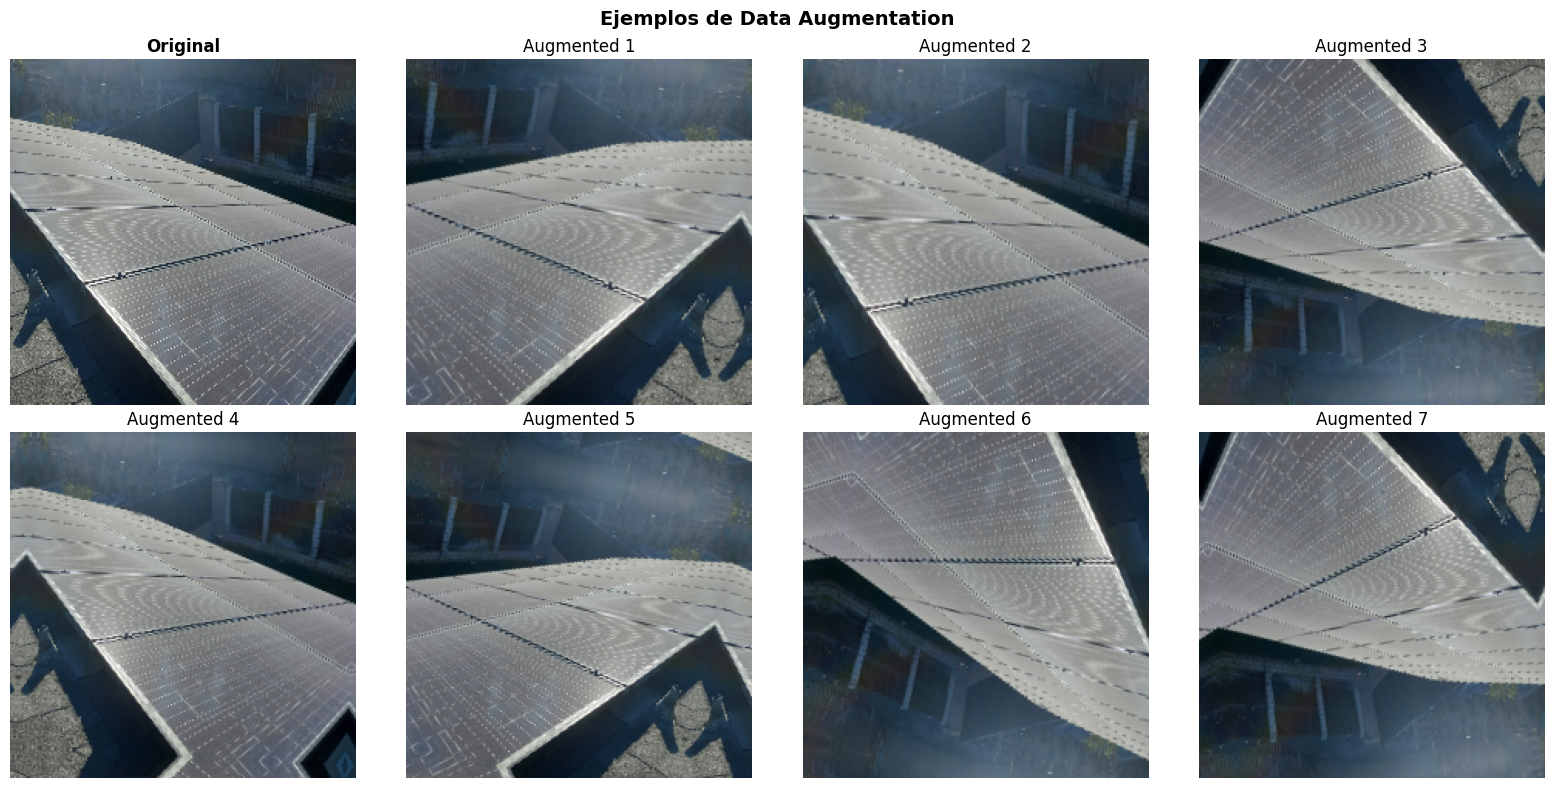

In [15]:
# Visualizar ejemplos de Data Augmentation
print("Ejemplos de Data Augmentation aplicado a una imagen:\n")

# Tomar una imagen de ejemplo
sample_img = X_train_final[0:1]  # Shape (1, 224, 224, 3)
sample_label = y_train_final[0:1]

# Generar versiones augmentadas
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Original
axes[0, 0].imshow(sample_img[0])
axes[0, 0].set_title('Original', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Generar 7 versiones augmentadas
aug_gen = train_datagen.flow(sample_img, sample_label, batch_size=1)

for i in range(7):
    row = (i + 1) // 4
    col = (i + 1) % 4
    aug_img = next(aug_gen)[0][0]
    axes[row, col].imshow(aug_img)
    axes[row, col].set_title(f'Augmented {i+1}', fontsize=12)
    axes[row, col].axis('off')

plt.suptitle('Ejemplos de Data Augmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## MODELO 2: Red Neuronal Convolucional (CNN desde cero)

In [16]:
print("="*80)
print("MODELO 2: RED NEURONAL CONVOLUCIONAL (CNN DESDE CERO)")
print("="*80 + "\n")

print("Características de las CNNs:")
print("  • Explotan la estructura espacial de las imágenes")
print("  • Aprenden características jerárquicas (bordes -> texturas -> objetos)")
print("  • Menos parámetros que DNN gracias a pesos compartidos")
print("  • Invariantes a traslaciones\n")

# Construir modelo CNN
print("Construyendo modelo CNN desde cero...")

model_cnn = models.Sequential([
    # Bloque 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', 
                  input_shape=(IMG_SIZE, IMG_SIZE, 3), name='conv1_1'),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1_2'),
    layers.MaxPooling2D((2, 2), name='pool1'),
    layers.BatchNormalization(name='bn1'),
    layers.Dropout(0.25, name='dropout1'),
    
    # Bloque 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2_1'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2_2'),
    layers.MaxPooling2D((2, 2), name='pool2'),
    layers.BatchNormalization(name='bn2'),
    layers.Dropout(0.25, name='dropout2'),
    
    # Bloque 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3_1'),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3_2'),
    layers.MaxPooling2D((2, 2), name='pool3'),
    layers.BatchNormalization(name='bn3'),
    layers.Dropout(0.25, name='dropout3'),
    
    # Bloque 4
    layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='conv4_1'),
    layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='conv4_2'),
    layers.MaxPooling2D((2, 2), name='pool4'),
    layers.BatchNormalization(name='bn4'),
    layers.Dropout(0.25, name='dropout4'),
    
    # Capas densas
    layers.Flatten(name='flatten'),
    layers.Dense(512, activation='relu', name='dense1'),
    layers.BatchNormalization(name='bn5'),
    layers.Dropout(0.5, name='dropout5'),
    
    layers.Dense(256, activation='relu', name='dense2'),
    layers.BatchNormalization(name='bn6'),
    layers.Dropout(0.5, name='dropout6'),
    
    # Salida
    layers.Dense(len(MAP_CLASSES), activation='softmax', name='output')
], name='CNN_Model')

# Compilar
model_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n✅ Modelo CNN compilado")
print("\n--- Resumen del Modelo CNN ---")
model_cnn.summary()

# Información de parámetros
trainable_params_cnn = np.sum([np.prod(v.shape) for v in model_cnn.trainable_weights])
print(f"\n📊 Parámetros entrenables: {trainable_params_cnn:,}")

print("\n" + "="*80)

MODELO 2: RED NEURONAL CONVOLUCIONAL (CNN DESDE CERO)

Características de las CNNs:
  • Explotan la estructura espacial de las imágenes
  • Aprenden características jerárquicas (bordes -> texturas -> objetos)
  • Menos parámetros que DNN gracias a pesos compartidos
  • Invariantes a traslaciones

Construyendo modelo CNN desde cero...

✅ Modelo CNN compilado

--- Resumen del Modelo CNN ---
Model: "CNN_Model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1_1 (Conv2D)            (None, 224, 224, 32)      896       
                                                                 
 conv1_2 (Conv2D)            (None, 224, 224, 32)      9248      
                                                                 
 pool1 (MaxPooling2D)        (None, 112, 112, 32)      0         
                                                                 
 bn1 (BatchNormalization)    (None, 112, 112, 32)      128   

In [17]:
print("="*80)
print("ENTRENAMIENTO MODELO 2: CNN")
print("="*80 + "\n")

# Callbacks para CNN
callbacks_cnn = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("Iniciando entrenamiento del modelo CNN con Data Augmentation...\n")

# Entrenar con los generadores de data augmentation
history_cnn = model_cnn.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks_cnn,
    verbose=1
)

print("\n" + "="*80)
print("ENTRENAMIENTO CNN COMPLETADO")
print("="*80)

ENTRENAMIENTO MODELO 2: CNN

Iniciando entrenamiento del modelo CNN con Data Augmentation...

Epoch 1/50
52/52 [==============================] - 14s 201ms/step - loss: 1.0277 - accuracy: 0.6294 - val_loss: 3.3392 - val_accuracy: 0.4171 - lr: 0.0010
Epoch 2/50
52/52 [==============================] - 9s 170ms/step - loss: 0.7942 - accuracy: 0.6801 - val_loss: 6.6164 - val_accuracy: 0.4171 - lr: 0.0010
Epoch 3/50
52/52 [==============================] - 9s 171ms/step - loss: 0.7397 - accuracy: 0.6880 - val_loss: 3.0948 - val_accuracy: 0.4171 - lr: 0.0010
Epoch 4/50
52/52 [==============================] - 9s 173ms/step - loss: 0.6616 - accuracy: 0.6966 - val_loss: 4.7248 - val_accuracy: 0.4171 - lr: 0.0010
Epoch 5/50
52/52 [==============================] - 9s 169ms/step - loss: 0.6671 - accuracy: 0.6947 - val_loss: 3.5515 - val_accuracy: 0.4171 - lr: 0.0010
Epoch 6/50
52/52 [==============================] - 9s 171ms/step - loss: 0.6330 - accuracy: 0.7070 - val_loss: 3.6390 - val_accur

EVALUACIÓN MODELO 2: CNN

📊 Resultados CNN en Test:
   Loss: 0.4647
   Accuracy: 0.7914 (79.14%)

Realizando predicciones CNN...

📊 Métricas Globales CNN:
   Accuracy: 0.7914
   Precision (macro): 0.8013
   Recall (macro): 0.7686
   F1-Score (macro): 0.7757


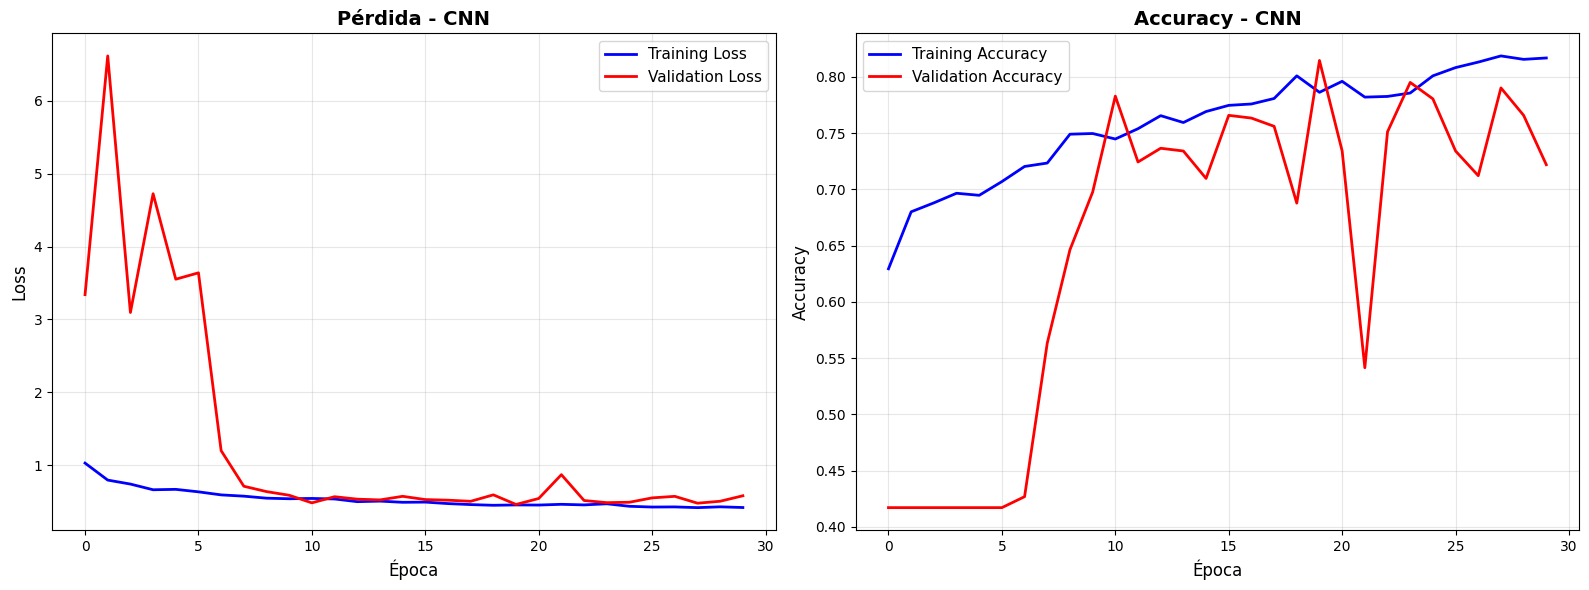

In [18]:
print("="*80)
print("EVALUACIÓN MODELO 2: CNN")
print("="*80 + "\n")

# Evaluar
test_loss_cnn, test_accuracy_cnn = model_cnn.evaluate(X_test_normalized, y_test_categorical, verbose=0)

print(f"📊 Resultados CNN en Test:")
print(f"   Loss: {test_loss_cnn:.4f}")
print(f"   Accuracy: {test_accuracy_cnn:.4f} ({test_accuracy_cnn*100:.2f}%)")

# Predicciones
print("\nRealizando predicciones CNN...")
y_pred_proba_cnn = model_cnn.predict(X_test_normalized, verbose=0)
y_pred_cnn = np.argmax(y_pred_proba_cnn, axis=1)

# Métricas
accuracy_cnn = accuracy_score(y_test_labels, y_pred_cnn)
precision_cnn, recall_cnn, f1_cnn, _ = precision_recall_fscore_support(
    y_test_labels, y_pred_cnn, average='macro', zero_division=0
)

print(f"\n📊 Métricas Globales CNN:")
print(f"   Accuracy: {accuracy_cnn:.4f}")
print(f"   Precision (macro): {precision_cnn:.4f}")
print(f"   Recall (macro): {recall_cnn:.4f}")
print(f"   F1-Score (macro): {f1_cnn:.4f}")

# Curvas de aprendizaje
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(history_cnn.history['loss'], label='Training Loss', linewidth=2, color='blue')
ax1.plot(history_cnn.history['val_loss'], label='Validation Loss', linewidth=2, color='red')
ax1.set_title('Pérdida - CNN', fontsize=14, fontweight='bold')
ax1.set_xlabel('Época', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(history_cnn.history['accuracy'], label='Training Accuracy', linewidth=2, color='blue')
ax2.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='red')
ax2.set_title('Accuracy - CNN', fontsize=14, fontweight='bold')
ax2.set_xlabel('Época', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)

## MODELO 3: Transfer Learning con CNN Pre-entrenada

## Construcción del Modelo 3: Transfer Learning

### Preprocesamiento Específico del Modelo

**⚠️ IMPORTANTE:** Cada modelo pre-entrenado requiere su propia función de preprocesamiento (`preprocess_input`) porque fueron entrenados con diferentes técnicas de normalización:

- **VGG16**: Resta la media de ImageNet por canal (RGB: [103.939, 116.779, 123.68])
- **ResNet50**: Igual que VGG16, normalización caffe-style
- **EfficientNet**: Normaliza a rango [-1, 1]
- **MobileNetV2**: Normaliza a rango [-1, 1]

Aplicar el preprocesamiento correcto es crucial para obtener buenos resultados.

In [52]:
print("="*80)
print("MODELO 3: TRANSFER LEARNING - CONSTRUCCIÓN")
print("="*80 + "\n")

print("Modelos pre-entrenados disponibles:")
print("  1. VGG16 - 138M parámetros (clásico, simple)")
print("  2. ResNet50 - 25.6M parámetros (residual connections)")
print("  3. EfficientNetB0 - 5.3M parámetros (eficiente, moderno)")
print("  4. MobileNetV2 - 3.5M parámetros (ligero, rápido)\n")

# Elegir modelo base (puedes cambiar esto)
MODEL_NAME = 'MobileNetV2'  # Opciones: 'VGG16', 'ResNet50', 'EfficientNetB0', 'MobileNetV2'

print(f"Modelo seleccionado: {MODEL_NAME}\n")

# Cargar modelo base pre-entrenado (sin la capa superior de clasificación)
if MODEL_NAME == 'VGG16':
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
elif MODEL_NAME == 'ResNet50':
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
elif MODEL_NAME == 'EfficientNetB0':
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
elif MODEL_NAME == 'MobileNetV2':
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

print(f"✅ Modelo base '{MODEL_NAME}' cargado con pesos de ImageNet")

# Congelar las capas del modelo base (Transfer Learning)
print("\nCongelando capas del modelo base...")
base_model.trainable = False

print(f"✅ Capas congeladas: {len(base_model.layers)}")
print("   Solo entrenaremos las nuevas capas superiores\n")

# Construir el modelo completo
print("Construyendo modelo con capas personalizadas...")

model_transfer = models.Sequential([
    # Modelo base pre-entrenado
    base_model,
    
    # Capas de pooling y clasificación personalizadas
    layers.GlobalAveragePooling2D(name='global_avg_pool'),
    
    layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001), name='dense1'),
    layers.BatchNormalization(name='bn1'),
    layers.Dropout(0.6, name='dropout1'),
    
    layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001), name='dense2'),
    layers.BatchNormalization(name='bn2'),
    layers.Dropout(0.6, name='dropout2'),
    
    # Capa de salida
    layers.Dense(len(MAP_CLASSES), activation='softmax', name='output')
], name=f'TransferLearning_{MODEL_NAME}')

# Compilar el modelo
model_transfer.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n✅ Modelo Transfer Learning compilado")
print("\n--- Resumen del Modelo Transfer Learning ---")
model_transfer.summary()

# Información de parámetros
trainable_params_transfer = np.sum([np.prod(v.shape) for v in model_transfer.trainable_weights])
non_trainable_params_transfer = np.sum([np.prod(v.shape) for v in model_transfer.non_trainable_weights])

print(f"\n📊 Parámetros del modelo Transfer Learning:")
print(f"   Totales: {trainable_params_transfer + non_trainable_params_transfer:,}")
print(f"   Entrenables: {trainable_params_transfer:,}")
print(f"   No entrenables (congelados): {non_trainable_params_transfer:,}")
print(f"   Porcentaje entrenable: {trainable_params_transfer/(trainable_params_transfer + non_trainable_params_transfer)*100:.2f}%")

print("\n" + "="*80)

MODELO 3: TRANSFER LEARNING - CONSTRUCCIÓN

Modelos pre-entrenados disponibles:
  1. VGG16 - 138M parámetros (clásico, simple)
  2. ResNet50 - 25.6M parámetros (residual connections)
  3. EfficientNetB0 - 5.3M parámetros (eficiente, moderno)
  4. MobileNetV2 - 3.5M parámetros (ligero, rápido)

Modelo seleccionado: MobileNetV2

✅ Modelo base 'MobileNetV2' cargado con pesos de ImageNet

Congelando capas del modelo base...
✅ Capas congeladas: 154
   Solo entrenaremos las nuevas capas superiores

Construyendo modelo con capas personalizadas...

✅ Modelo Transfer Learning compilado

--- Resumen del Modelo Transfer Learning ---
Model: "TransferLearning_MobileNetV2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 g

## Preprocesamiento Específico para Transfer Learning

In [53]:
print("="*80)
print("PREPROCESAMIENTO ESPECÍFICO DEL MODELO")
print("="*80 + "\n")

# Seleccionar la función de preprocesamiento específica del modelo
print(f"Aplicando preprocesamiento para {MODEL_NAME}...")

if MODEL_NAME == 'VGG16':
    preprocess_func = vgg16_preprocess
    print("  • VGG16: Normalización caffe-style (resta media ImageNet por canal)")
elif MODEL_NAME == 'ResNet50':
    preprocess_func = resnet50_preprocess
    print("  • ResNet50: Normalización caffe-style (resta media ImageNet por canal)")
elif MODEL_NAME == 'EfficientNetB0':
    preprocess_func = efficientnet_preprocess
    print("  • EfficientNet: Normalización a rango [-1, 1]")
elif MODEL_NAME == 'MobileNetV2':
    preprocess_func = mobilenet_preprocess
    print("  • MobileNetV2: Normalización a rango [-1, 1]")
    
print(f"  Shape original de los datos: {X_train_final.shape}")
print(f"  Rango original: [{X_train_final.min():.2f}, {X_train_final.max():.2f}]")

# Aplicar preprocesamiento a los datos
# IMPORTANTE: preprocess_input espera valores en el rango [0, 255]
print("\nPreprocesando datos de entrenamiento...")
X_train_transfer = preprocess_func((X_train_final * 255.0).astype('float32'))
print(f"  Shape: {X_train_transfer.shape}")
print(f"  Rango después de preprocess: [{X_train_transfer.min():.2f}, {X_train_transfer.max():.2f}]")

print("\nPreprocesando datos de validación...")
X_val_transfer = preprocess_func((X_val * 255.0).astype('float32'))
print(f"  Shape: {X_val_transfer.shape}")
print(f"  Rango después de preprocess: [{X_val_transfer.min():.2f}, {X_val_transfer.max():.2f}]")

print("\nPreprocesando datos de test...")
# X_test_normalized está en [0, 1], lo convertimos a [0, 255] primero
X_test_transfer = preprocess_func((X_test_normalized * 255.0).astype('float32'))
print(f"  Shape: {X_test_transfer.shape}")
print(f"  Rango después de preprocess: [{X_test_transfer.min():.2f}, {X_test_transfer.max():.2f}]")

print("\n✅ Preprocesamiento específico aplicado correctamente")
print("\n" + "="*80)

PREPROCESAMIENTO ESPECÍFICO DEL MODELO

Aplicando preprocesamiento para MobileNetV2...
  • MobileNetV2: Normalización a rango [-1, 1]
  Shape original de los datos: (1638, 224, 224, 3)
  Rango original: [0.00, 1.00]

Preprocesando datos de entrenamiento...
  Shape: (1638, 224, 224, 3)
  Rango después de preprocess: [-1.00, 1.00]

Preprocesando datos de validación...
  Shape: (410, 224, 224, 3)
  Rango después de preprocess: [-1.00, 1.00]

Preprocesando datos de test...
  Shape: (513, 224, 224, 3)
  Rango después de preprocess: [-1.00, 1.00]

✅ Preprocesamiento específico aplicado correctamente



## Entrenamiento del Modelo 3: Transfer Learning

### Generadores de Datos para Transfer Learning

**IMPORTANTE:** Los datos ya están preprocesados con la función específica del modelo, por lo que los generadores NO deben aplicar normalización adicional.

In [54]:
print("="*80)
print("PREPARACIÓN DE GENERADORES PARA TRANSFER LEARNING")
print("="*80 + "\n")

# Generador para Transfer Learning con Data Augmentation (SIN normalización adicional)
train_datagen_transfer = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.15,
    shear_range=0.15,
    fill_mode='reflect'
)

# Para validation, sin augmentation ni normalización adicional
val_datagen_transfer = ImageDataGenerator()

# Crear generadores con los datos preprocesados
train_generator_transfer = train_datagen_transfer.flow(
    X_train_transfer, y_train_final,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_generator_transfer = val_datagen_transfer.flow(
    X_val_transfer, y_val,
    batch_size=BATCH_SIZE,
    seed=SEED
)

print("✅ Generadores de Transfer Learning configurados")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Steps por época (training): {len(train_generator_transfer)}")
print(f"   Steps por época (validation): {len(val_generator_transfer)}")
print(f"   Datos preprocesados con: {MODEL_NAME} preprocess_input")

print("\n" + "="*80)

PREPARACIÓN DE GENERADORES PARA TRANSFER LEARNING

✅ Generadores de Transfer Learning configurados
   Batch size: 32
   Steps por época (training): 52
   Steps por época (validation): 13
   Datos preprocesados con: MobileNetV2 preprocess_input



In [55]:
print("="*80)
print("ENTRENAMIENTO MODELO 3: TRANSFER LEARNING")
print("="*80 + "\n")

# Configurar callbacks
callbacks_transfer = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks configurados:")
print("  • EarlyStopping: patience=10, restore_best_weights=True")
print("  • ReduceLROnPlateau: factor=0.5, patience=5\n")

print("Iniciando entrenamiento Transfer Learning...\n")
print(f"Épocas máximas: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Usando GPU: {len(tf.config.list_physical_devices('GPU')) > 0}\n")
print("="*80 + "\n")

# Entrenar el modelo con los generadores específicos de Transfer Learning
history_transfer = model_transfer.fit(
    train_generator_transfer,
    epochs=EPOCHS,
    validation_data=val_generator_transfer,
    callbacks=callbacks_transfer,
    verbose=1
)

print("\n" + "="*80)
print("ENTRENAMIENTO TRANSFER LEARNING COMPLETADO")
print("="*80)

ENTRENAMIENTO MODELO 3: TRANSFER LEARNING

Callbacks configurados:
  • EarlyStopping: patience=10, restore_best_weights=True
  • ReduceLROnPlateau: factor=0.5, patience=5

Iniciando entrenamiento Transfer Learning...

Épocas máximas: 50
Batch size: 32
Usando GPU: True


Epoch 1/50
52/52 [==============================] - 13s 196ms/step - loss: 2.1239 - accuracy: 0.6178 - val_loss: 1.7124 - val_accuracy: 0.7098 - lr: 0.0010
Epoch 2/50
52/52 [==============================] - 9s 174ms/step - loss: 1.8476 - accuracy: 0.6954 - val_loss: 1.6478 - val_accuracy: 0.7439 - lr: 0.0010
Epoch 3/50
52/52 [==============================] - 9s 176ms/step - loss: 1.7374 - accuracy: 0.7216 - val_loss: 1.6382 - val_accuracy: 0.7317 - lr: 0.0010
Epoch 4/50
52/52 [==============================] - 9s 173ms/step - loss: 1.6306 - accuracy: 0.7411 - val_loss: 1.5141 - val_accuracy: 0.7634 - lr: 0.0010
Epoch 5/50
52/52 [==============================] - 9s 175ms/step - loss: 1.5470 - accuracy: 0.7515 - val_lo

## Análisis de Curvas de Aprendizaje - Transfer Learning

ANÁLISIS DE CURVAS DE APRENDIZAJE - TRANSFER LEARNING



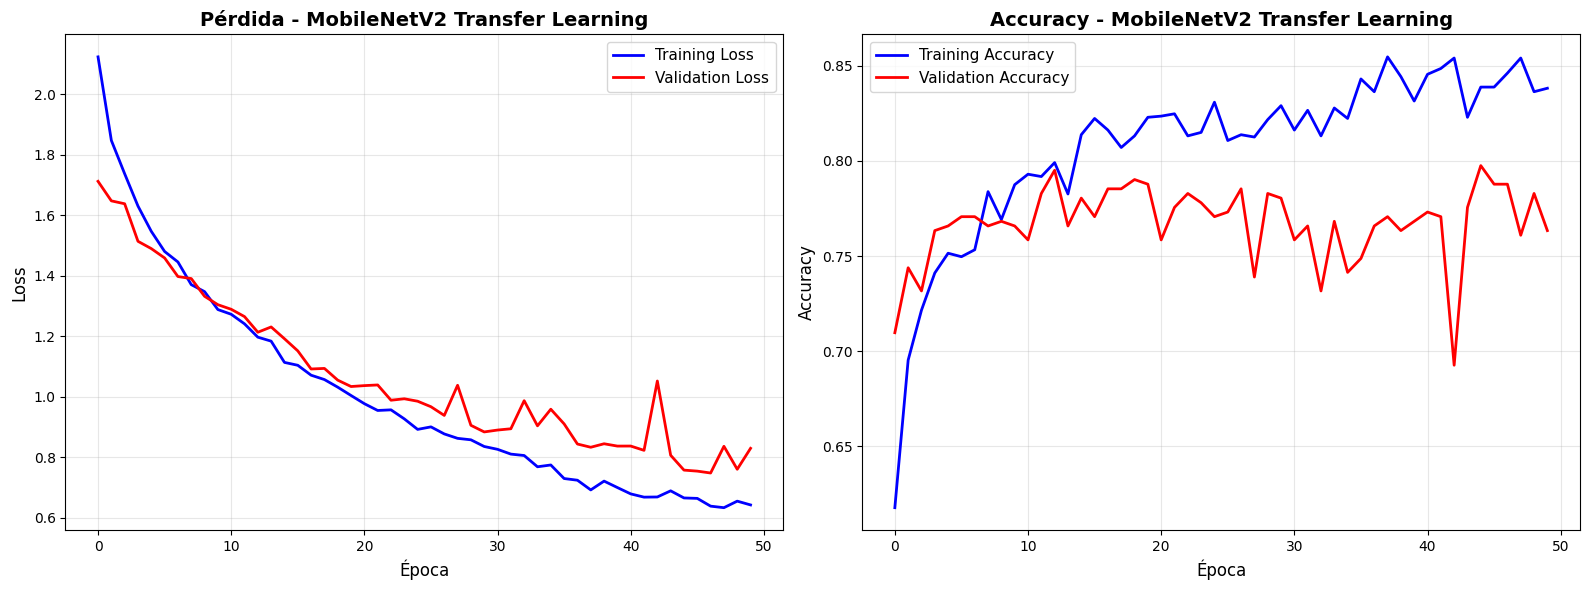

Épocas entrenadas: 50
Mejor época: 47
Mejor val_loss: 0.7480
Mejor val_accuracy: 0.7878 (78.78%)

Accuracy final Training: 0.8382
Accuracy final Validation: 0.7634
Diferencia: 0.0748
⚠️ Ligero overfitting (diferencia > 5%)



In [56]:
print("="*80)
print("ANÁLISIS DE CURVAS DE APRENDIZAJE - TRANSFER LEARNING")
print("="*80 + "\n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de pérdida
ax1.plot(history_transfer.history['loss'], label='Training Loss', linewidth=2, color='blue')
ax1.plot(history_transfer.history['val_loss'], label='Validation Loss', linewidth=2, color='red')
ax1.set_title(f'Pérdida - {MODEL_NAME} Transfer Learning', fontsize=14, fontweight='bold')
ax1.set_xlabel('Época', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Gráfico de accuracy
ax2.plot(history_transfer.history['accuracy'], label='Training Accuracy', linewidth=2, color='blue')
ax2.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='red')
ax2.set_title(f'Accuracy - {MODEL_NAME} Transfer Learning', fontsize=14, fontweight='bold')
ax2.set_xlabel('Época', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas del entrenamiento
epochs_trained = len(history_transfer.history['loss'])
best_epoch = np.argmin(history_transfer.history['val_loss'])
best_val_loss = history_transfer.history['val_loss'][best_epoch]
best_val_acc = history_transfer.history['val_accuracy'][best_epoch]

print(f"Épocas entrenadas: {epochs_trained}")
print(f"Mejor época: {best_epoch + 1}")
print(f"Mejor val_loss: {best_val_loss:.4f}")
print(f"Mejor val_accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")

# Análisis de overfitting
final_train_acc = history_transfer.history['accuracy'][-1]
final_val_acc = history_transfer.history['val_accuracy'][-1]
diff_acc = final_train_acc - final_val_acc

print(f"\nAccuracy final Training: {final_train_acc:.4f}")
print(f"Accuracy final Validation: {final_val_acc:.4f}")
print(f"Diferencia: {diff_acc:.4f}")

if diff_acc > 0.1:
    print("⚠️ Posible overfitting detectado (diferencia > 10%)")
elif diff_acc > 0.05:
    print("⚠️ Ligero overfitting (diferencia > 5%)")
else:
    print("✅ Modelo bien generalizado")

print("\n" + "="*80)

## Evaluación del Modelo 3: Transfer Learning

In [57]:
print("="*80)
print("EVALUACIÓN MODELO 3: TRANSFER LEARNING EN TEST")
print("="*80 + "\n")

# Evaluar el modelo con datos preprocesados específicos del modelo
test_loss_transfer, test_accuracy_transfer = model_transfer.evaluate(X_test_transfer, y_test_categorical, verbose=0)

print(f"📊 Resultados Transfer Learning en Test:")
print(f"   Loss: {test_loss_transfer:.4f}")
print(f"   Accuracy: {test_accuracy_transfer:.4f} ({test_accuracy_transfer*100:.2f}%)")

# Realizar predicciones con datos preprocesados
print("\nRealizando predicciones Transfer Learning...")
y_pred_proba_transfer = model_transfer.predict(X_test_transfer, verbose=0)
y_pred_transfer = np.argmax(y_pred_proba_transfer, axis=1)

# Calcular métricas
accuracy_transfer = accuracy_score(y_test_labels, y_pred_transfer)
precision_transfer, recall_transfer, f1_transfer, support = precision_recall_fscore_support(
    y_test_labels, y_pred_transfer, average='macro', zero_division=0
)

print(f"\n📊 Métricas Globales Transfer Learning:")
print(f"   Accuracy: {accuracy_transfer:.4f}")
print(f"   Precision (macro): {precision_transfer:.4f}")
print(f"   Recall (macro): {recall_transfer:.4f}")
print(f"   F1-Score (macro): {f1_transfer:.4f}")

print("\n" + "="*80)

EVALUACIÓN MODELO 3: TRANSFER LEARNING EN TEST

📊 Resultados Transfer Learning en Test:
   Loss: 0.7535
   Accuracy: 0.7934 (79.34%)

Realizando predicciones Transfer Learning...

📊 Métricas Globales Transfer Learning:
   Accuracy: 0.7934
   Precision (macro): 0.8222
   Recall (macro): 0.7630
   F1-Score (macro): 0.7714



## Fase 2 - Fine Tuning del Modelo Transfer Learning

Después de entrenar la parte superior del modelo pre-entrenado, ahora vamos a afinar (fine-tune) algunas capas convolucionales para mejorar el rendimiento.

En esta fase, desbloquearemos las últimas capas convolucionales del modelo base y entrenaremos todo el modelo con una tasa de aprendizaje más baja para ajustar los pesos finamente.


FASE 2: FINE-TUNING (DESBLOQUEO DE POTENCIAL PARA MobileNetV2)

Estrategia adaptativa para MobileNetV2:
   • Total capas: 154
   • Congelando las primeras 100 capas (Fondo)
   • Entrenando las últimas 54 capas (Cabeza)
   • Capas BatchNormalization mantenidas congeladas: 52

Modelo re-compilado con Learning Rate: 1e-05
Iniciando 30 épocas extra de ajuste fino...
Epoch 51/80
52/52 [==============================] - 12s 182ms/step - loss: 0.3637 - accuracy: 0.9274 - val_loss: 0.6290 - val_accuracy: 0.8341 - lr: 1.0000e-05
Epoch 52/80
52/52 [==============================] - 9s 174ms/step - loss: 0.3434 - accuracy: 0.9396 - val_loss: 0.6343 - val_accuracy: 0.8244 - lr: 1.0000e-05
Epoch 53/80
52/52 [==============================] - 9s 172ms/step - loss: 0.3287 - accuracy: 0.9451 - val_loss: 0.6768 - val_accuracy: 0.8146 - lr: 1.0000e-05
Epoch 54/80
52/52 [==============================] - 9s 177ms/step - loss: 0.3270 - accuracy: 0.9487 - val_loss: 0.6416 - val_accuracy: 0.8390 - lr: 1.00

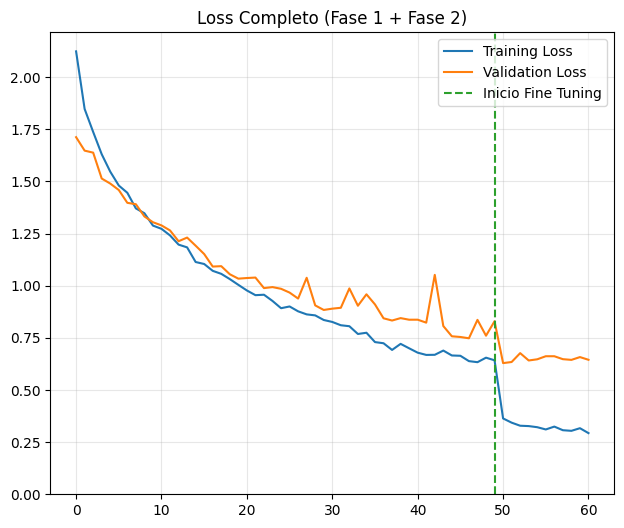

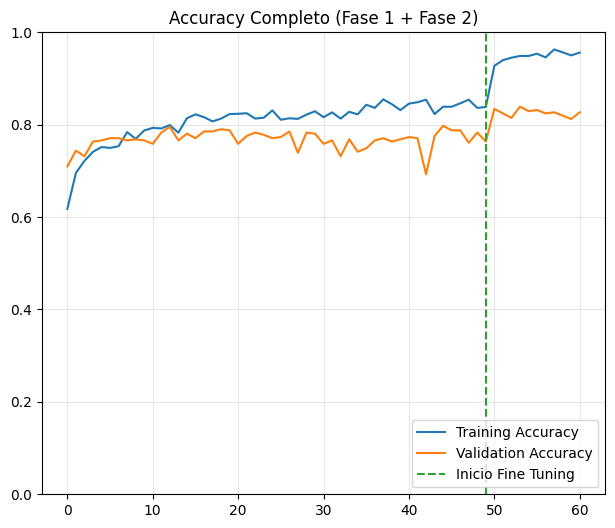


EVALUACIÓN FINAL POST FINE-TUNING

Accuracy Final en Test: 0.8441 (84.41%)
Mejora obtenida con Fine-Tuning: +5.07%


In [70]:
print("\n" + "="*80)
print(f"FASE 2: FINE-TUNING (DESBLOQUEO DE POTENCIAL PARA {MODEL_NAME})")
print("="*80 + "\n")

# 1. Configuración de capas
# ---------------------------------------------------------
base_model.trainable = True
total_layers = len(base_model.layers)

# Estrategia: Entrenar el top 35% de las capas
ratio_trainable = 0.35
fine_tune_at = int(total_layers * (1 - ratio_trainable))

print(f"Estrategia adaptativa para {MODEL_NAME}:")
print(f"   • Total capas: {total_layers}")
print(f"   • Congelando las primeras {fine_tune_at} capas (Fondo)")
print(f"   • Entrenando las últimas {total_layers - fine_tune_at} capas (Cabeza)")

# Congelar capas base
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# IMPORTANTE: Forzar congelación de BatchNormalization
# Esto evita que las estadísticas aprendidas en ImageNet se rompan con el Fine-Tuning
# Es crucial para MobileNetV2 y EfficientNet
frozen_bn = 0
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
        frozen_bn += 1

print(f"   • Capas BatchNormalization mantenidas congeladas: {frozen_bn}")

# 2. Re-compilar (Low Learning Rate)
# ---------------------------------------------------------
# Usamos un LR 100 veces más pequeño (1e-5) para "pulir" sin romper
fine_tune_lr = 1e-5

model_transfer.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=fine_tune_lr),
    metrics=['accuracy']
)

print(f"\nModelo re-compilado con Learning Rate: {fine_tune_lr}")

# 3. Entrenamiento de Fine-Tuning
# ---------------------------------------------------------
fine_tune_epochs = 30  # Épocas adicionales
total_epochs = EPOCHS + fine_tune_epochs

print(f"Iniciando {fine_tune_epochs} épocas extra de ajuste fino...")

history_fine = model_transfer.fit(
    train_generator_transfer,
    epochs=total_epochs,
    initial_epoch=history_transfer.epoch[-1] + 1, # Continuar donde lo dejamos
    validation_data=val_generator_transfer,
    callbacks=callbacks_transfer, # Reusamos los mismos callbacks
    verbose=1
)

# 4. Unir Historias para Visualización Continua
# ---------------------------------------------------------
acc = history_transfer.history['accuracy'] + history_fine.history['accuracy']
val_acc = history_transfer.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history_transfer.history['loss'] + history_fine.history['loss']
val_loss = history_transfer.history['val_loss'] + history_fine.history['val_loss']

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, max(plt.ylim())])
plt.plot([history_transfer.epoch[-1],history_transfer.epoch[-1]], plt.ylim(), label='Inicio Fine Tuning', linestyle='--')
plt.legend(loc='upper right')
plt.title(f'Loss Completo (Fase 1 + Fase 2)')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 2)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0, 1])
plt.plot([history_transfer.epoch[-1],history_transfer.epoch[-1]], plt.ylim(), label='Inicio Fine Tuning', linestyle='--')
plt.legend(loc='lower right')
plt.title(f'Accuracy Completo (Fase 1 + Fase 2)')
plt.grid(True, alpha=0.3)
plt.show()

# 5. Evaluación Final Definitiva
# ---------------------------------------------------------
print("\n" + "="*80)
print("EVALUACIÓN FINAL POST FINE-TUNING")
print("="*80 + "\n")

loss_fine, acc_fine = model_transfer.evaluate(X_test_transfer, y_test_categorical, verbose=0)
print(f"Accuracy Final en Test: {acc_fine:.4f} ({acc_fine*100:.2f}%)")

# Mejora obtenida
improvement = acc_fine - test_accuracy_transfer
print(f"Mejora obtenida con Fine-Tuning: {improvement*100:+.2f}%")

## COMPARACIÓN DE LOS 3 MODELOS

COMPARACIÓN FINAL: DNN vs CNN vs TRANSFER LEARNING + FINE TUNING

Recalculando métricas con los pesos del Fine Tuning...
--- TABLA DE RESULTADOS FINALES ---

                                        Modelo  Test Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)  Test Loss  Parámetros Entrenables
                                  DNN (Densas)       0.721248           0.727306        0.691128          0.694420   0.533109                77237122
                              CNN (desde cero)       0.791423           0.801253        0.768598          0.775656   0.464659                26997218
Transfer Learning + Fine Tuning\n(MobileNetV2)       0.844055           0.848479        0.829689          0.835803   0.539672                 2628866

🏆 GANADOR ABSOLUTO: Transfer Learning + Fine Tuning (MobileNetV2)
   Accuracy Final: 0.8441 (84.41%)


C:\Users\TRENDINGPC\AppData\Local\Temp\ipykernel_14932\1144100203.py:116: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(resultados_comparacion['Modelo'], rotation=10, ha='center')
C:\Users\TRENDINGPC\AppData\Local\Temp\ipykernel_14932\1144100203.py:131: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(resultados_comparacion['Modelo'], rotation=10, ha='center')
C:\Users\TRENDINGPC\AppData\Local\Temp\ipykernel_14932\1144100203.py:175: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax7.set_xticklabels(resultados_comparacion['Modelo'], rotation=10, ha='center')


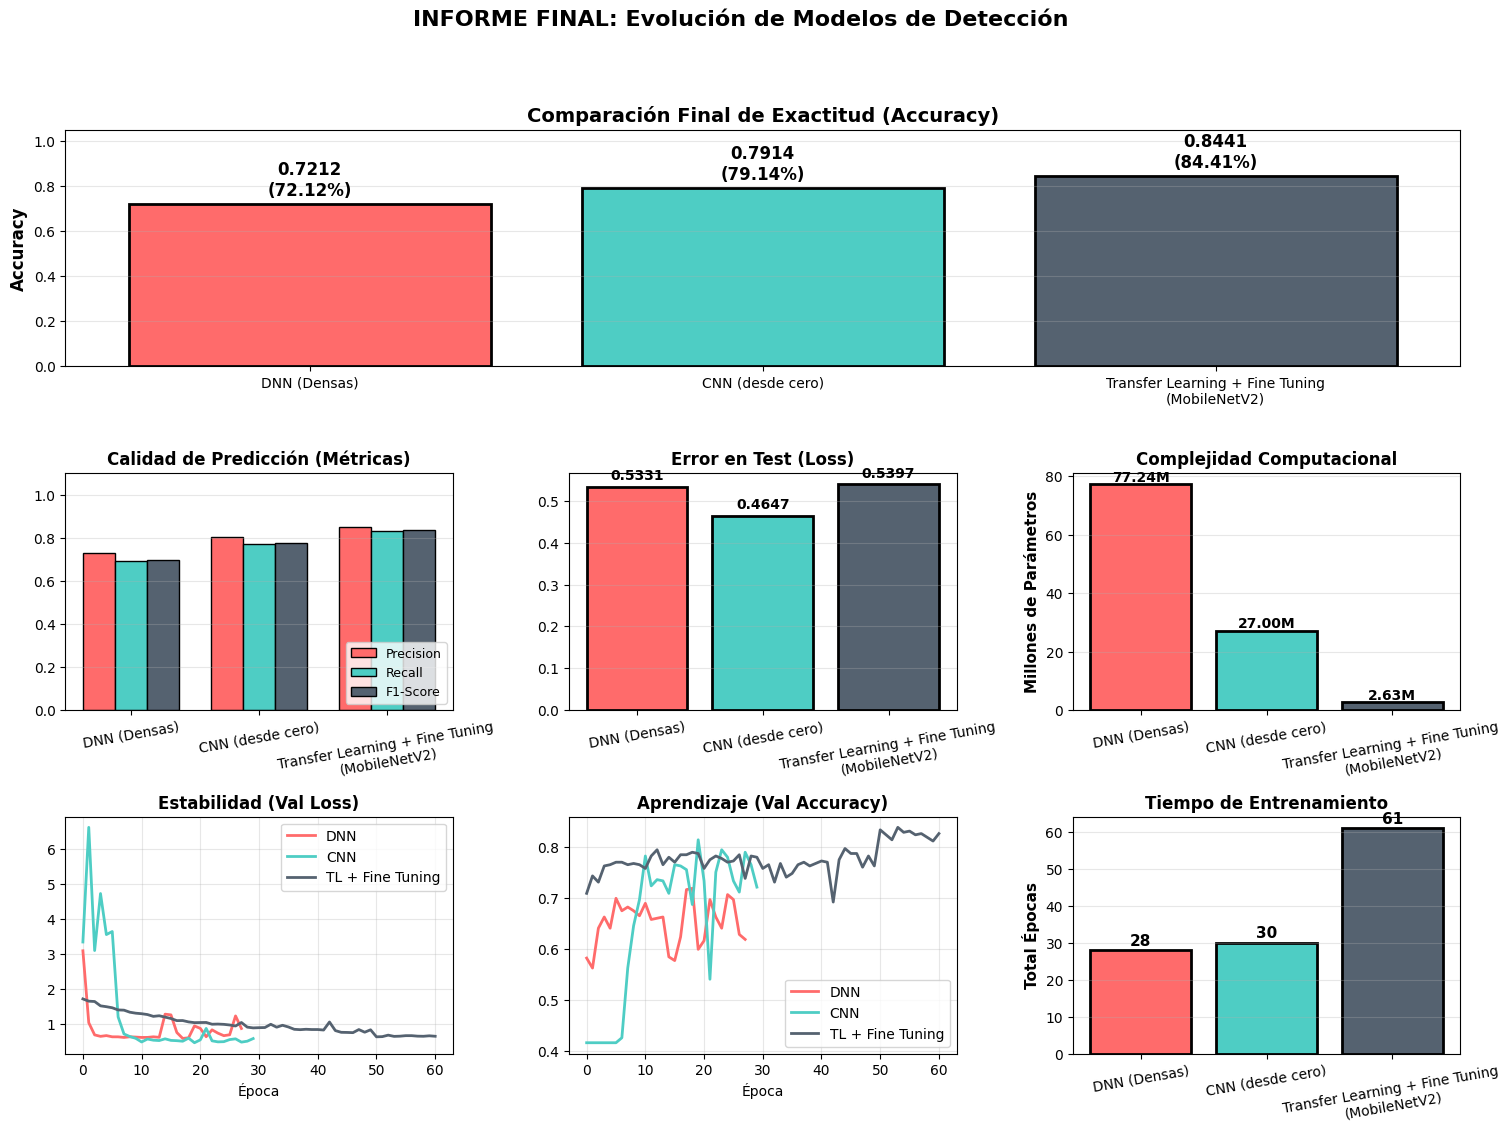

In [76]:
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("="*80)
print("COMPARACIÓN FINAL: DNN vs CNN vs TRANSFER LEARNING + FINE TUNING")
print("="*80 + "\n")

# -------------------------------------------------------------------------
# 1. PREPARAR DATOS DEL MODELO FINAL (Fase 1 + Fase 2)
# -------------------------------------------------------------------------

# Recalcular predicciones con el modelo ya ajustado (Fine-Tuned)
print("Recalculando métricas con los pesos del Fine Tuning...")
y_pred_proba_fine = model_transfer.predict(X_test_transfer, verbose=0)
y_pred_fine = np.argmax(y_pred_proba_fine, axis=1)

# Calcular métricas detalladas (Precision, Recall, F1)
precision_fine, recall_fine, f1_fine, _ = precision_recall_fscore_support(
    y_test_labels, y_pred_fine, average='macro', zero_division=0
)

# Recalcular parámetros entrenables (ahora son más que en la Fase 1)
trainable_params_fine = np.sum([np.prod(v.shape) for v in model_transfer.trainable_weights])

# Clase auxiliar para combinar los historiales de Fase 1 y Fase 2
class CombinedHistory:
    def __init__(self):
        self.history = {}
        # Concatenamos las listas de métricas de ambas fases
        self.history['loss'] = history_transfer.history['loss'] + history_fine.history['loss']
        self.history['val_loss'] = history_transfer.history['val_loss'] + history_fine.history['val_loss']
        self.history['accuracy'] = history_transfer.history['accuracy'] + history_fine.history['accuracy']
        self.history['val_accuracy'] = history_transfer.history['val_accuracy'] + history_fine.history['val_accuracy']

history_combined = CombinedHistory()

# -------------------------------------------------------------------------
# 2. CREAR DATAFRAME COMPARATIVO
# -------------------------------------------------------------------------

# Definimos el nombre exacto que pediste
nombre_modelo_final = f"Transfer Learning + Fine Tuning\n({MODEL_NAME})"

resultados_comparacion = pd.DataFrame({
    'Modelo': ['DNN (Densas)', 'CNN (desde cero)', nombre_modelo_final],
    'Test Accuracy': [test_accuracy_dnn, test_accuracy_cnn, acc_fine],
    'Precision (macro)': [precision_dnn, precision_cnn, precision_fine],
    'Recall (macro)': [recall_dnn, recall_cnn, recall_fine],
    'F1-Score (macro)': [f1_dnn, f1_cnn, f1_fine],
    'Test Loss': [test_loss_dnn, test_loss_cnn, loss_fine],
    'Parámetros Entrenables': [
        trainable_params_dnn,
        trainable_params_cnn,
        trainable_params_fine
    ]
})

print("--- TABLA DE RESULTADOS FINALES ---\n")
print(resultados_comparacion.to_string(index=False))

# Identificar ganador
best_model_idx = resultados_comparacion['Test Accuracy'].idxmax()
best_model_name = resultados_comparacion.loc[best_model_idx, 'Modelo'].replace('\n', ' ')
best_accuracy = resultados_comparacion.loc[best_model_idx, 'Test Accuracy']

print(f"\n🏆 GANADOR ABSOLUTO: {best_model_name}")
print(f"   Accuracy Final: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

# -------------------------------------------------------------------------
# 3. VISUALIZACIÓN GRÁFICA
# -------------------------------------------------------------------------
fig = plt.figure(figsize=(18, 12))
# Ajustamos el espaciado para que quepan los nombres largos
gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.3)

colors_bars = ['#FF6B6B', '#4ECDC4', '#556270'] # Rojo, Turquesa, Gris Azulado

# A. Accuracy Global
ax1 = fig.add_subplot(gs[0, :])
bars = ax1.bar(resultados_comparacion['Modelo'], 
               resultados_comparacion['Test Accuracy'], 
               color=colors_bars, edgecolor='black', linewidth=2)
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Comparación Final de Exactitud (Accuracy)', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 1.05)
ax1.grid(axis='y', alpha=0.3)
# Etiquetas encima de las barras
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.4f}\n({height*100:.2f}%)',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# B. Métricas Detalladas (Precision, Recall, F1)
ax2 = fig.add_subplot(gs[1, 0])
x = np.arange(len(resultados_comparacion))
width = 0.25
ax2.bar(x - width, resultados_comparacion['Precision (macro)'], width, label='Precision', color='#FF6B6B', edgecolor='black')
ax2.bar(x, resultados_comparacion['Recall (macro)'], width, label='Recall', color='#4ECDC4', edgecolor='black')
ax2.bar(x + width, resultados_comparacion['F1-Score (macro)'], width, label='F1-Score', color='#556270', edgecolor='black')
ax2.set_title('Calidad de Predicción (Métricas)', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(resultados_comparacion['Modelo'], rotation=10, ha='center')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 1.1)

# C. Pérdida (Loss) - Cuanto menos mejor
ax3 = fig.add_subplot(gs[1, 1])
bars_loss = ax3.bar(resultados_comparacion['Modelo'], 
                    resultados_comparacion['Test Loss'],
                    color=colors_bars, edgecolor='black', linewidth=2)
ax3.set_title('Error en Test (Loss)', fontsize=12, fontweight='bold')
ax3.set_xticklabels(resultados_comparacion['Modelo'], rotation=10, ha='center')
ax3.grid(axis='y', alpha=0.3)
for bar in bars_loss:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# D. Eficiencia (Parámetros)
ax4 = fig.add_subplot(gs[1, 2])
params_millions = resultados_comparacion['Parámetros Entrenables'] / 1_000_000
bars_params = ax4.bar(resultados_comparacion['Modelo'], 
                      params_millions,
                      color=colors_bars, edgecolor='black', linewidth=2)
ax4.set_ylabel('Millones de Parámetros', fontsize=11, fontweight='bold')
ax4.set_title('Complejidad Computacional', fontsize=12, fontweight='bold')
ax4.set_xticklabels(resultados_comparacion['Modelo'], rotation=10, ha='center')
ax4.grid(axis='y', alpha=0.3)
for bar in bars_params:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.05,
             f'{height:.2f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- CURVAS DE APRENDIZAJE ---
histories_plot = [
    ('DNN', history_dnn, '#FF6B6B'),
    ('CNN', history_cnn, '#4ECDC4'),
    ('TL + Fine Tuning', history_combined, '#556270') # Nombre corto para la leyenda
]

# E. Evolución Loss Validación
ax5 = fig.add_subplot(gs[2, 0])
for name, hist, color in histories_plot:
    ax5.plot(hist.history['val_loss'], label=name, linewidth=2, color=color)
ax5.set_xlabel('Época', fontsize=10)
ax5.set_title('Estabilidad (Val Loss)', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

# F. Evolución Accuracy Validación
ax6 = fig.add_subplot(gs[2, 1])
for name, hist, color in histories_plot:
    ax6.plot(hist.history['val_accuracy'], label=name, linewidth=2, color=color)
ax6.set_xlabel('Época', fontsize=10)
ax6.set_title('Aprendizaje (Val Accuracy)', fontsize=12, fontweight='bold')
ax6.legend(loc='lower right')
ax6.grid(True, alpha=0.3)

# G. Tiempo / Épocas Totales
ax7 = fig.add_subplot(gs[2, 2])
epochs_total = [
    len(history_dnn.history['loss']),
    len(history_cnn.history['loss']),
    len(history_combined.history['loss'])
]
bars_epochs = ax7.bar(resultados_comparacion['Modelo'], 
                      epochs_total,
                      color=colors_bars, edgecolor='black', linewidth=2)
ax7.set_ylabel('Total Épocas', fontsize=11, fontweight='bold')
ax7.set_title('Tiempo de Entrenamiento', fontsize=12, fontweight='bold')
ax7.set_xticklabels(resultados_comparacion['Modelo'], rotation=10, ha='center')
ax7.grid(axis='y', alpha=0.3)
for bar in bars_epochs:
    height = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle(f'INFORME FINAL: Evolución de Modelos de Detección', 
             fontsize=16, fontweight='bold', y=0.98)
plt.show()

print("\n" + "="*80)

## Matrices de Confusión Comparativas

MATRICES DE CONFUSIÓN COMPARATIVAS (FINAL)



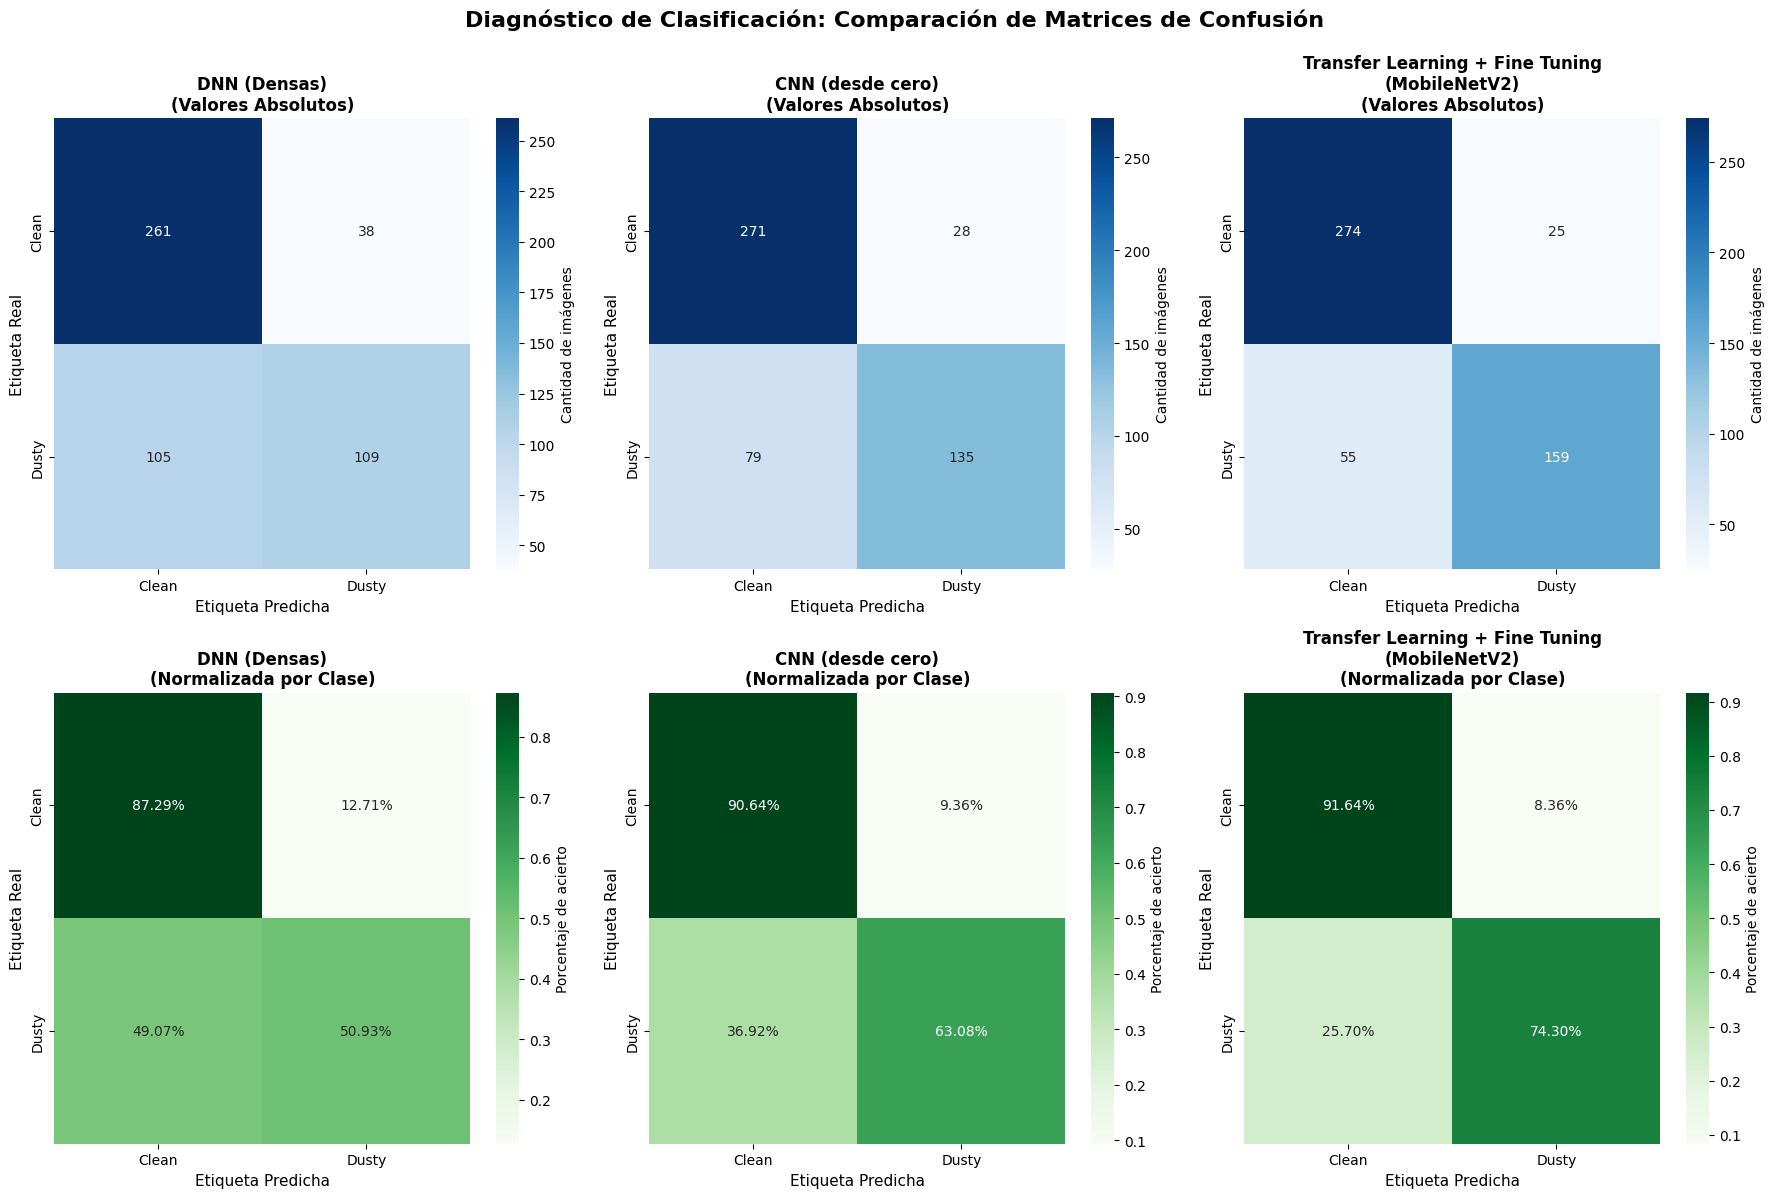

In [79]:
print("="*80)
print("MATRICES DE CONFUSIÓN COMPARATIVAS (FINAL)")
print("="*80 + "\n")

# Aseguramos que tenemos las etiquetas de las clases
class_names_list = [CLASS_NAMES[i] for i in sorted(MAP_CLASSES.keys())]

# 1. Calcular matrices de confusión
# Usamos y_pred_fine que calculamos en el bloque anterior
cm_dnn = confusion_matrix(y_test_labels, y_pred_dnn)
cm_cnn = confusion_matrix(y_test_labels, y_pred_cnn)
cm_fine = confusion_matrix(y_test_labels, y_pred_fine)

# 2. Configuración de la visualización
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
nombre_tf_ft = f'Transfer Learning + Fine Tuning\n({MODEL_NAME})'

# Lista de matrices para iterar
matrices = [
    (cm_dnn, 'DNN (Densas)'),
    (cm_cnn, 'CNN (desde cero)'),
    (cm_fine, nombre_tf_ft)
]

# FILA 1: VALORES ABSOLUTOS
# Permite ver cuántas imágenes exactas se han clasificado bien/mal
for idx, (cm, title) in enumerate(matrices):
    ax = axes[0, idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_list,
                yticklabels=class_names_list,
                cbar_kws={'label': 'Cantidad de imágenes'},
                ax=ax)
    ax.set_title(f'{title}\n(Valores Absolutos)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Etiqueta Real', fontsize=11)
    ax.set_xlabel('Etiqueta Predicha', fontsize=11)

# FILA 2: VALORES NORMALIZADOS (PORCENTAJES)
# Permite ver la precisión relativa por clase, independientemente del número de imágenes
for idx, (cm, title) in enumerate(matrices):
    ax = axes[1, idx]
    # Normalización por filas (Recall por clase)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens', # Cambiamos a verde para diferenciar
                xticklabels=class_names_list,
                yticklabels=class_names_list,
                cbar_kws={'label': 'Porcentaje de acierto'},
                ax=ax)
    ax.set_title(f'{title}\n(Normalizada por Clase)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Etiqueta Real', fontsize=11)
    ax.set_xlabel('Etiqueta Predicha', fontsize=11)

plt.suptitle('Diagnóstico de Clasificación: Comparación de Matrices de Confusión', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n" + "="*80)

## Visualización Comparativa de Predicciones

VISUALIZACIÓN COMPARATIVA DE PREDICCIONES FINALES



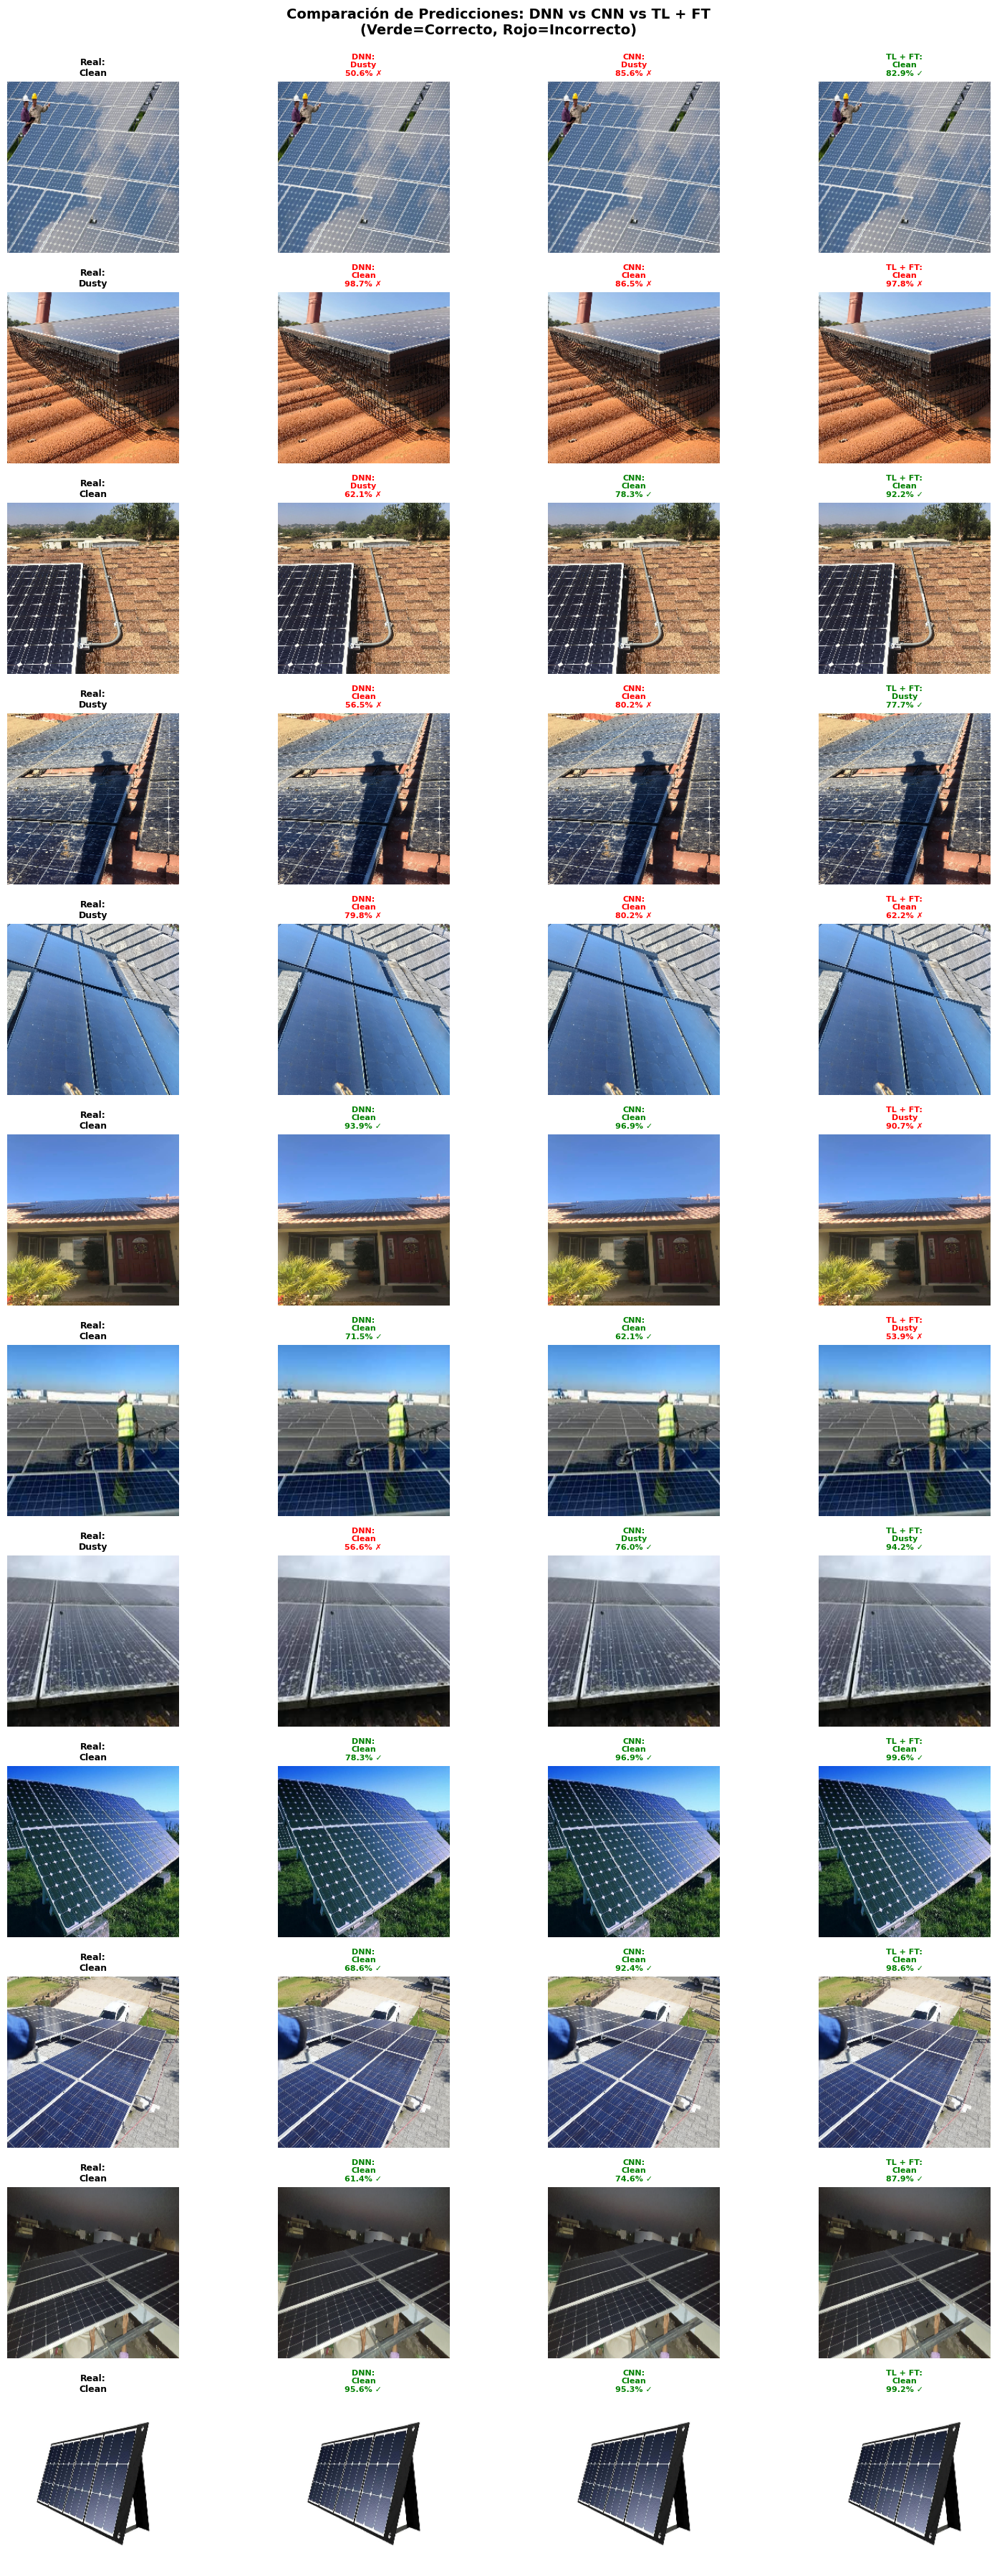

Estadísticas de predicciones correctas:
   DNN: 370/513 (72.12%)
   CNN: 406/513 (79.14%)
   TL + FT: 433/513 (84.41%)

Análisis de acuerdos:
   Todos los modelos aciertan: 310/513 (60.43%)
   Todos los modelos fallan: 32/513 (6.24%)



In [80]:
print('='*80)
print('VISUALIZACIÓN COMPARATIVA DE PREDICCIONES FINALES')
print('='*80 + '\n')

X_test_display = (X_test_normalized * 255).astype(np.uint8)

np.random.seed(42)
num_samples = min(12, len(X_test_normalized))
random_indices = np.random.choice(len(X_test_normalized), num_samples, replace=False)

fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples * 3))

nombre_final = 'TL + FT'

for i, idx in enumerate(random_indices):
    ax = axes[i, 0] if num_samples > 1 else axes[0]
    ax.imshow(X_test_display[idx])
    true_label = CLASS_NAMES[y_test_labels[idx]]
    ax.set_title(f'Real:\n{true_label}', fontsize=9, fontweight='bold')
    ax.axis('off')
    
    predictions = [
        (y_pred_dnn[idx], y_pred_proba_dnn[idx], 'DNN'),
        (y_pred_cnn[idx], y_pred_proba_cnn[idx], 'CNN'),
        (y_pred_fine[idx], y_pred_proba_fine[idx], nombre_final)
    ]
    
    for j, (pred, proba, name) in enumerate(predictions):
        ax = axes[i, j + 1] if num_samples > 1 else axes[j + 1]
        ax.imshow(X_test_display[idx])
        
        pred_label = CLASS_NAMES[pred]
        confidence = proba[pred] * 100
        
        is_correct = pred == y_test_labels[idx]
        color = 'green' if is_correct else 'red'
        symbol = '✓' if is_correct else '✗'
        
        title = f'{name}:\n{pred_label}\n{confidence:.1f}% {symbol}'
        ax.set_title(title, fontsize=8, color=color, fontweight='bold')
        ax.axis('off')

plt.suptitle(f'Comparación de Predicciones: DNN vs CNN vs {nombre_final}\n(Verde=Correcto, Rojo=Incorrecto)',
             fontsize=14, fontweight='bold', y=0.998)
plt.tight_layout()
plt.show()

print('Estadísticas de predicciones correctas:')
print(f'   DNN: {np.sum(y_pred_dnn == y_test_labels)}/{len(y_test_labels)} ({np.mean(y_pred_dnn == y_test_labels)*100:.2f}%)')
print(f'   CNN: {np.sum(y_pred_cnn == y_test_labels)}/{len(y_test_labels)} ({np.mean(y_pred_cnn == y_test_labels)*100:.2f}%)')
print(f'   {nombre_final}: {np.sum(y_pred_fine == y_test_labels)}/{len(y_test_labels)} ({np.mean(y_pred_fine == y_test_labels)*100:.2f}%)')

todos_correctos = (y_pred_dnn == y_test_labels) & (y_pred_cnn == y_test_labels) & (y_pred_fine == y_test_labels)
todos_incorrectos = (y_pred_dnn != y_test_labels) & (y_pred_cnn != y_test_labels) & (y_pred_fine != y_test_labels)

print(f'\nAnálisis de acuerdos:')
print(f'   Todos los modelos aciertan: {np.sum(todos_correctos)}/{len(y_test_labels)} ({np.mean(todos_correctos)*100:.2f}%)')
print(f'   Todos los modelos fallan: {np.sum(todos_incorrectos)}/{len(y_test_labels)} ({np.mean(todos_incorrectos)*100:.2f}%)')

print('\n' + '='*80)

## Análisis Detallado por Clase

ANÁLISIS DETALLADO POR CLASE: INFORME FINAL

--- Métricas por Clase - MODELO DNN ---
              precision    recall  f1-score   support

       Clean       0.71      0.87      0.78       299
       Dusty       0.74      0.51      0.60       214

    accuracy                           0.72       513
   macro avg       0.73      0.69      0.69       513
weighted avg       0.72      0.72      0.71       513


--- Métricas por Clase - MODELO CNN ---
              precision    recall  f1-score   support

       Clean       0.77      0.91      0.84       299
       Dusty       0.83      0.63      0.72       214

    accuracy                           0.79       513
   macro avg       0.80      0.77      0.78       513
weighted avg       0.80      0.79      0.79       513


--- Métricas por Clase - Transfer Learning + FT ---
              precision    recall  f1-score   support

       Clean       0.83      0.92      0.87       299
       Dusty       0.86      0.74      0.80       214

   

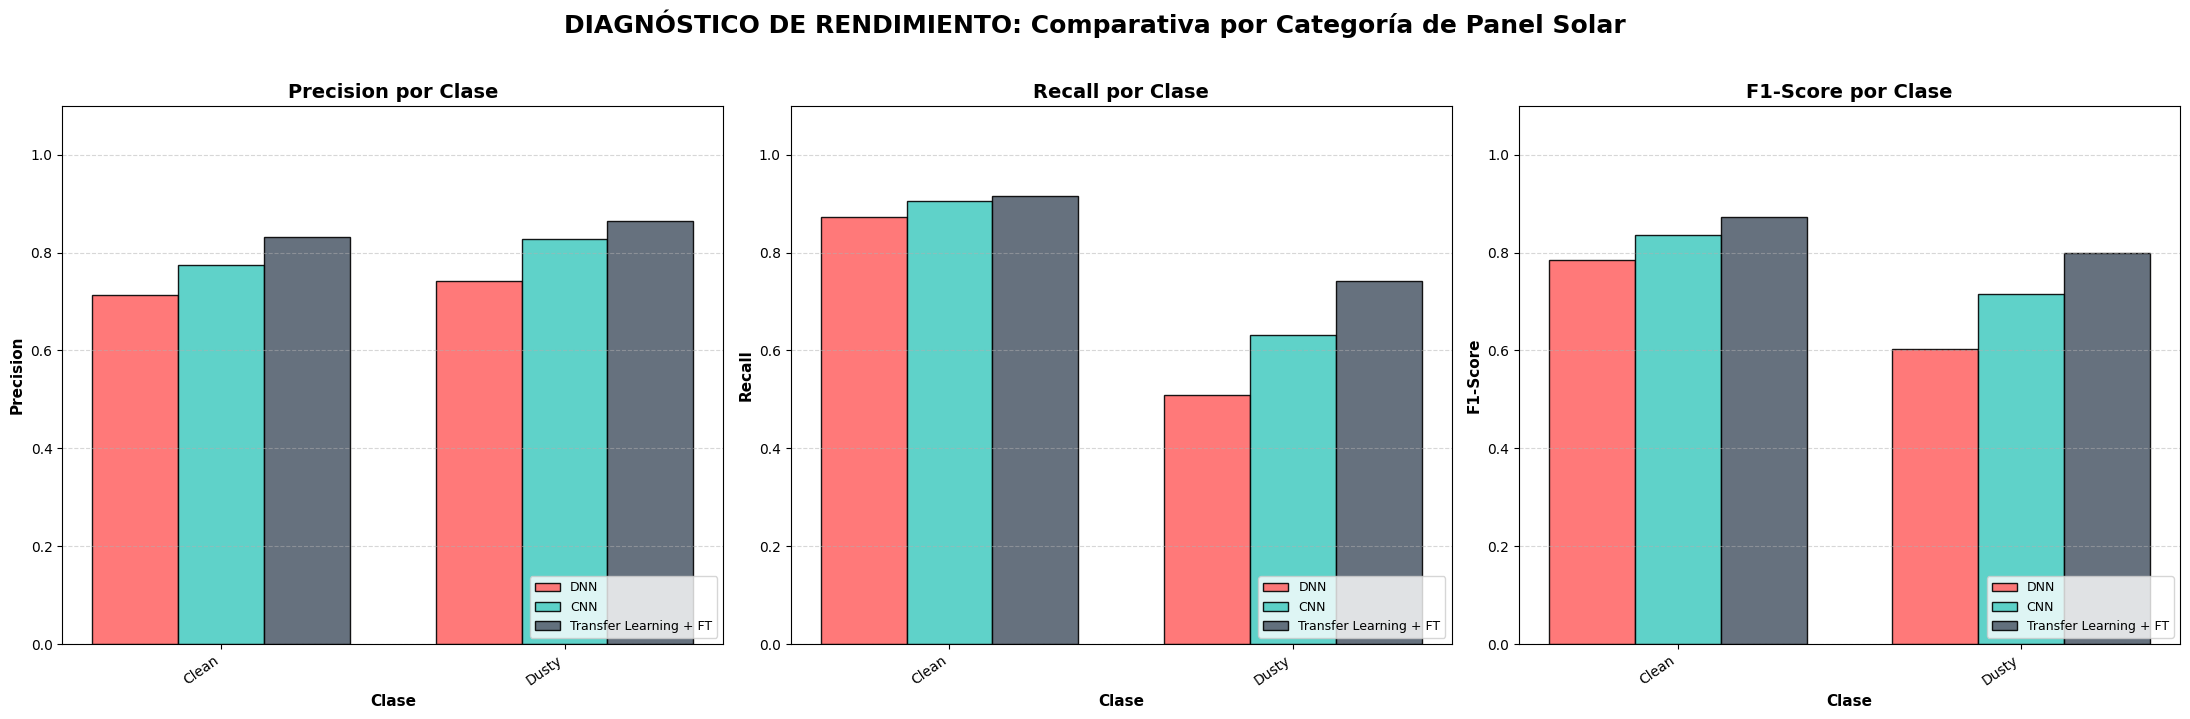

In [81]:
print("="*80)
print("ANÁLISIS DETALLADO POR CLASE: INFORME FINAL")
print("="*80 + "\n")

# Aseguramos el orden de las clases
class_names_list = [CLASS_NAMES[i] for i in sorted(MAP_CLASSES.keys())]
nombre_final_label = 'Transfer Learning + FT'

# 1. Reportes de Clasificación por Consola
print("--- Métricas por Clase - MODELO DNN ---")
print(classification_report(y_test_labels, y_pred_dnn, 
                          target_names=class_names_list, 
                          zero_division=0))

print("\n--- Métricas por Clase - MODELO CNN ---")
print(classification_report(y_test_labels, y_pred_cnn, 
                          target_names=class_names_list, 
                          zero_division=0))

print(f"\n--- Métricas por Clase - {nombre_final_label} ---")
print(classification_report(y_test_labels, y_pred_fine, # Usamos predicciones del Fine Tuning
                          target_names=class_names_list, 
                          zero_division=0))

# 2. Calcular métricas por clase para la visualización
precision_dnn_per_class, recall_dnn_per_class, f1_dnn_per_class, _ = \
    precision_recall_fscore_support(y_test_labels, y_pred_dnn, average=None, zero_division=0)
    
precision_cnn_per_class, recall_cnn_per_class, f1_cnn_per_class, _ = \
    precision_recall_fscore_support(y_test_labels, y_pred_cnn, average=None, zero_division=0)
    
precision_fine_per_class, recall_fine_per_class, f1_fine_per_class, _ = \
    precision_recall_fscore_support(y_test_labels, y_pred_fine, average=None, zero_division=0)

# 3. Crear DataFrame comparativo organizado
df_comparison_per_class = pd.DataFrame({
    'Clase': class_names_list * 3,
    'Modelo': (['DNN'] * len(class_names_list) + 
               ['CNN'] * len(class_names_list) + 
               [nombre_final_label] * len(class_names_list)),
    'Precision': np.concatenate([precision_dnn_per_class, precision_cnn_per_class, precision_fine_per_class]),
    'Recall': np.concatenate([recall_dnn_per_class, recall_cnn_per_class, recall_fine_per_class]),
    'F1-Score': np.concatenate([f1_dnn_per_class, f1_cnn_per_class, f1_fine_per_class])
})

# 4. Visualización de Alto Nivel
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
metrics = ['Precision', 'Recall', 'F1-Score']
# Mantenemos la paleta de colores coherente
colors = {'DNN': '#FF6B6B', 'CNN': '#4ECDC4', nombre_final_label: '#556270'}

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    x = np.arange(len(class_names_list))
    width = 0.25
    
    for i, modelo in enumerate(['DNN', 'CNN', nombre_final_label]):
        data = df_comparison_per_class[df_comparison_per_class['Modelo'] == modelo][metric].values
        offset = (i - 1) * width
        ax.bar(x + offset, data, width, label=modelo, color=colors[modelo], edgecolor='black', alpha=0.9)
    
    ax.set_xlabel('Clase', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.set_title(f'{metric} por Clase', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names_list, rotation=35, ha='right')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_ylim(0, 1.1)

plt.suptitle('DIAGNÓSTICO DE RENDIMIENTO: Comparativa por Categoría de Panel Solar', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()